Table of Contents <!-- id: table-of-contents -->
- [ATAC-Seq analysis in Human pre-implantation embryonic development](#atac-seq-analysis-in-human-pre-implantation-embryonic-development)
  - [Retrieval of fastq files](#retrieval-of-fastq-files)
  - [Check read quality](#check-read-quality)
  - [Remove the adapters](#remove-the-adapters)
    - [Let's check the QC again](#let's-check-the-qc-again)
  - [Alignment of reads](#alignment-of-reads)
    - [Convert SAM to BAM](#convert-sam-to-bam)
    - [Filter Reads](#filter-reads)
    - [Alignment Quality Control](#alignment-quality-control)
      - [1. Alignment Statistics: Generate alignment statistics to confirm mapping efficiency](#1-alignment-statistics:-generate-alignment-statistics-to-confirm-mapping-efficiency)
      - [2. Inspect Read Distribution: Visualize aligned reads using a genome browser like IGV](#2-inspect-read-distribution:-visualize-aligned-reads-using-a-genome-browser-like-igv)
    - [Genome Coverage](#genome-coverage)
      - [Heatmap plot <a name="heatmap"></a>](#heatmap-plot-<a-name="heatmap"></a>)
  - [Peak Calling using MACS2](#peak-calling-using-macs2)
    - [Find differential ATAC-seq signal, genome-wide](#find-differential-atac-seq-signal-genome-wide)
  - [motif discovery](#motif-discovery)
    - [RSAT peak-motifs](#rsat-peak-motifs)
    - [PWM and track enrichment <a name="track"></a>](#pwm-and-track-enrichment-<a-name="track"></a>)
    - [Additional Functional analysis](#additional-functional-analysis)
- [conclusion](#conclusion)

# ATAC-Seq analysis in Human pre-implantation embryonic development 

The fertilization process in humans initiates extensive chromatin reorganization, pivotal for early embryonic development. Researchers investigate chromatin states in human preimplantation development using an improved assay for transposase-accessible chromatin with high-throughput sequencing  (ATAC-seq). They found widespread open chromatin regions before `zygotic genome activation (ZGA)`. `Embryonic Genome Activation(EGA)`: the embryo no longer relies exclusively on maternally mRNAs and proteins and can synthesise these factors from the embryonic genome. The accessible chromatin loci are readily found at CpG-rich promoters. The original paper is ([Chromatin analysis in human early development reveals epigenetic transition during ZGA](https://www.nature.com/articles/s41586-018-0080-8#Sec29)). It help to advance our understanding of epigenetic reprogramming during human early development and in vitro fertilization.

To characterize the chromatin states during preimplantation development, specifically focusing on chromatin accessibility patterns before and after zygotic genome activation (ZGA), and identify the regulatory regions driving early embryogenesis.

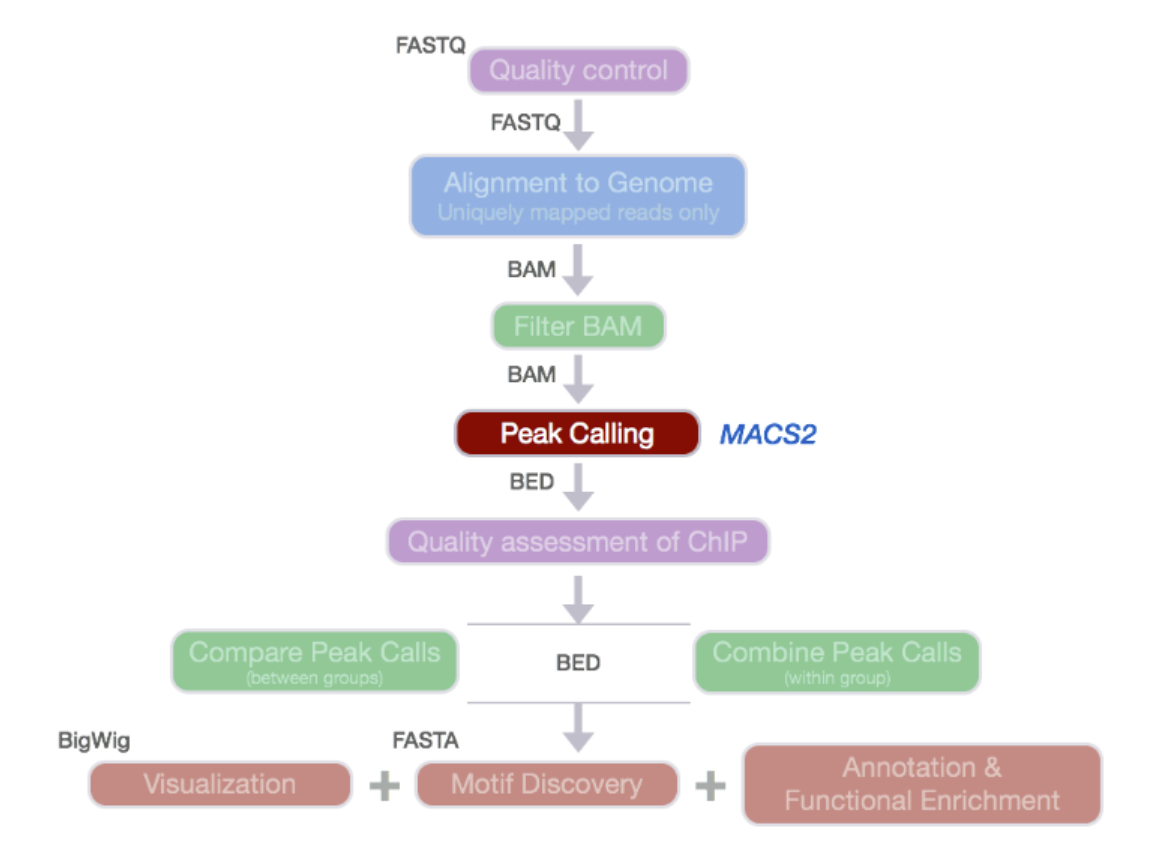

## Retrieval of fastq files

The datasets are taken from GEO database with the accession number [GSE101571](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE101571). 

`Two-cell embryos (SRR5837316)`: Representing the pre-ZGA stage.

`Eight-cell embryos (SRR5837330)`: Capturing early post-ZGA dynamics.

`Inner Cell Masses (ICMs) (SRR5837337)`: Isolated from embryonic day 5 (E5) blastocysts, encompassing epiblast and primitive endoderm cells.

`Human embryonic stem cells (hESCs) (SRR5837344)`: Serving as a control for pluripotent chromatin states.

In [1]:
#create a directory for our analysis
#mkdir -p /mnt/storage/$USER/jupyternotebooks/Epigenome/data
cd /mnt/storage/$USER/jupyternotebooks/Epigenome

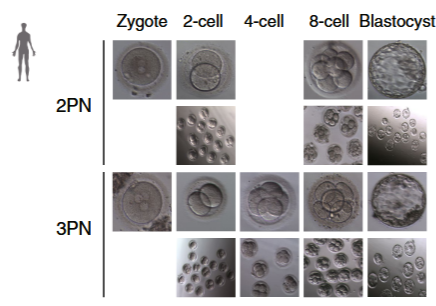

In [2]:
for SRR in SRR5837316 SRR5837330 SRR5837337 SRR5837342; do
    if [ "$SRR" == "SRR5837316" ]; then
        if [ ! -f ./data/"${SRR}_1.fastq" ] || [ ! -f ./data/"${SRR}_2.fastq" ]; then
            echo "Downloading and processing $SRR (2-cell)"
            prefetch $SRR
            fasterq-dump $SRR --threads 8 -O ./data
        else
            echo "2-cell files already exist, skipping $SRR"
        fi
    elif [ "$SRR" == "SRR5837330" ]; then
        if [ ! -f ./data/"${SRR}_1.fastq" ] || [ ! -f ./data/"${SRR}_2.fastq" ]; then
            echo "Downloading and processing $SRR (8-cell)"
            prefetch $SRR
            fasterq-dump $SRR --threads 8 -O ./data
        else
            echo "8-cell files already exist, skipping $SRR"
        fi
    elif [ "$SRR" == "SRR5837337" ]; then
        if [ ! -f ./data/"${SRR}_1.fastq" ] || [ ! -f ./data/"${SRR}_2.fastq" ]; then
            echo "Downloading and processing $SRR (ICM)"
            prefetch $SRR
            fasterq-dump $SRR --threads 8 -O ./data
        else
            echo "ICM files already exist, skipping $SRR"
        fi
    elif [ "$SRR" == "SRR5837342" ]; then
        if [ ! -f ./data/"${SRR}_1.fastq" ] || [ ! -f ./data/"${SRR}_2.fastq" ]; then
            echo "Downloading and processing $SRR (hESC)"
            prefetch $SRR
            fasterq-dump $SRR --threads 8 -O ./data
        else
            echo "hESC files already exist, skipping $SRR"
        fi
    fi
done



2025-01-02T19:37:13 prefetch.3.0.0: Current preference is set to retrieve SRA Normalized Format files with full base quality scores.
2025-01-02T19:37:14 prefetch.3.0.0: 1) Downloading 'SRR5837316'...
2025-01-02T19:37:14 prefetch.3.0.0: SRA Normalized Format file is being retrieved, if this is different from your preference, it may be due to current file availability.
2025-01-02T19:37:14 prefetch.3.0.0:  Downloading via HTTPS...
2025-01-02T19:39:02 prefetch.3.0.0:  HTTPS download succeed
2025-01-02T19:39:09 prefetch.3.0.0:  'SRR5837316' is valid
2025-01-02T19:39:09 prefetch.3.0.0: 1) 'SRR5837316' was downloaded successfully
2025-01-02T19:39:09 prefetch.3.0.0: 'SRR5837316' has 0 unresolved dependencies
spots read      : 28,216,346
reads read      : 56,432,692
reads written   : 56,432,692
8-cell files already exist, skipping SRR5837330
ICM files already exist, skipping SRR5837337
hESC files already exist, skipping SRR5837342


In [1]:
for SRR in SRR5837316 SRR5837330 SRR5837337 SRR5837342; do
    # rename the fastq files
    if [ "$SRR" == "SRR5837316" ]; then
        mv ./data/"${SRR}_1.fastq" ./data/01_fastq/2-cell_1.fastq
        mv ./data/"${SRR}_2.fastq" ./data/01_fastq/2-cell_2.fastq
    elif [ "$SRR" == "SRR5837330" ]; then
        mv ./data/"${SRR}_1.fastq" ./data/01_fastq/8-cell_1.fastq
        mv ./data/"${SRR}_2.fastq" ./data/01_fastq/8-cell_2.fastq
    elif [ "$SRR" == "SRR5837337" ]; then
        mv ./data/"${SRR}_1.fastq" ./data/01_fastq/ICM_1.fastq
        mv ./data/"${SRR}_2.fastq" ./data/01_fastq/ICM_2.fastq
    elif [ "$SRR" == "SRR5837342" ]; then
        mv ./data/"${SRR}_1.fastq" ./data/01_fastq/hESC_1.fastq
        mv ./data/"${SRR}_2.fastq" ./data/01_fastq/hESC_2.fastq
    fi
done

SyntaxError: invalid decimal literal (480281893.py, line 4)

In [4]:
ls ./data/01_fastq

2-cell_1.fastq  8-cell_1.fastq  hESC_1.fastq  ICM_1.fastq
2-cell_2.fastq  8-cell_2.fastq  hESC_2.fastq  ICM_2.fastq


To calculate the total number of reads for each FASTQ file, you can use the `wc -l` command to count the lines and divide by 4 (since each read occupies four lines). Below is a script to process all FASTQ files in the ./data/01_fastq folder and print the number of reads for each file

In [8]:
# Iterate over all FASTQ files and count the reads
for FASTQ_FILE in ./data/01_fastq/*.fastq; do
    # Count lines, divide by 4, and print the number of reads
    READ_COUNT=$(wc -l "$FASTQ_FILE" | awk '{ print $1/4 }')
    echo "File: $FASTQ_FILE - Reads: $READ_COUNT"
done

File: ./data/01_fastq/2-cell_1.fastq - Reads: 28216346
File: ./data/01_fastq/2-cell_2.fastq - Reads: 28216346
File: ./data/01_fastq/8-cell_1.fastq - Reads: 17450350
File: ./data/01_fastq/8-cell_2.fastq - Reads: 17450350
File: ./data/01_fastq/hESC_1.fastq - Reads: 12077701
File: ./data/01_fastq/hESC_2.fastq - Reads: 12077701
File: ./data/01_fastq/ICM_1.fastq - Reads: 46723019
File: ./data/01_fastq/ICM_2.fastq - Reads: 46723019


## Check read quality 


In [5]:
# Create the target directory to store FastQC results
mkdir -p ./data/02_qc

For each input file, FastQC generates:
An HTML file (viewable in a browser for quality reports).
A ZIP file (containing detailed statistics and analysis results).

In [6]:
# Iterate over all FASTQ files in the ./data/01_fastq folder and run FastQC
for FASTQ_FILE in ./data/01_fastq/*.fastq; do
    echo "Running FastQC on $FASTQ_FILE"
    fastqc "$FASTQ_FILE" --outdir=./data/02_qc --threads 8
done

echo "FastQC analysis completed. Results are saved in ./data/02_qc."

Running FastQC on ./data/01_fastq/2-cell_1.fastq
Started analysis of 2-cell_1.fastq
Approx 5% complete for 2-cell_1.fastq
Approx 10% complete for 2-cell_1.fastq
Approx 15% complete for 2-cell_1.fastq
Approx 20% complete for 2-cell_1.fastq
Approx 25% complete for 2-cell_1.fastq
Approx 30% complete for 2-cell_1.fastq
Approx 35% complete for 2-cell_1.fastq
Approx 40% complete for 2-cell_1.fastq
Approx 45% complete for 2-cell_1.fastq
Approx 50% complete for 2-cell_1.fastq
Approx 55% complete for 2-cell_1.fastq
Approx 60% complete for 2-cell_1.fastq
Approx 65% complete for 2-cell_1.fastq
Approx 70% complete for 2-cell_1.fastq
Approx 75% complete for 2-cell_1.fastq
Approx 80% complete for 2-cell_1.fastq
Approx 85% complete for 2-cell_1.fastq
Approx 90% complete for 2-cell_1.fastq
Approx 95% complete for 2-cell_1.fastq
Analysis complete for 2-cell_1.fastq
Running FastQC on ./data/01_fastq/2-cell_2.fastq
Started analysis of 2-cell_2.fastq
Approx 5% complete for 2-cell_2.fastq
Approx 10% comple

In [9]:
ls ./data/02_qc

2-cell_1_fastqc.html  8-cell_2_fastqc.html  ICM_1_fastqc.html
2-cell_1_fastqc.zip   8-cell_2_fastqc.zip   ICM_1_fastqc.zip
2-cell_2_fastqc.html  hESC_1_fastqc.html    ICM_2_fastqc.html
2-cell_2_fastqc.zip   hESC_1_fastqc.zip     ICM_2_fastqc.zip
8-cell_1_fastqc.html  hESC_2_fastqc.html
8-cell_1_fastqc.zip   hESC_2_fastqc.zip


Now we can open the report `fastqc.html` and check the quality of the data. 
For this data set, the sequencing quality scores are very good but the presence of adapter sequences is significant and must be addressed.And Kmer Content in this FastQC report highlights an unusual distribution of specific Kmers (short sequence fragments) at particular positions within the reads which indicates abnormal short sequence fragments presence. We will perform adapter trimming 

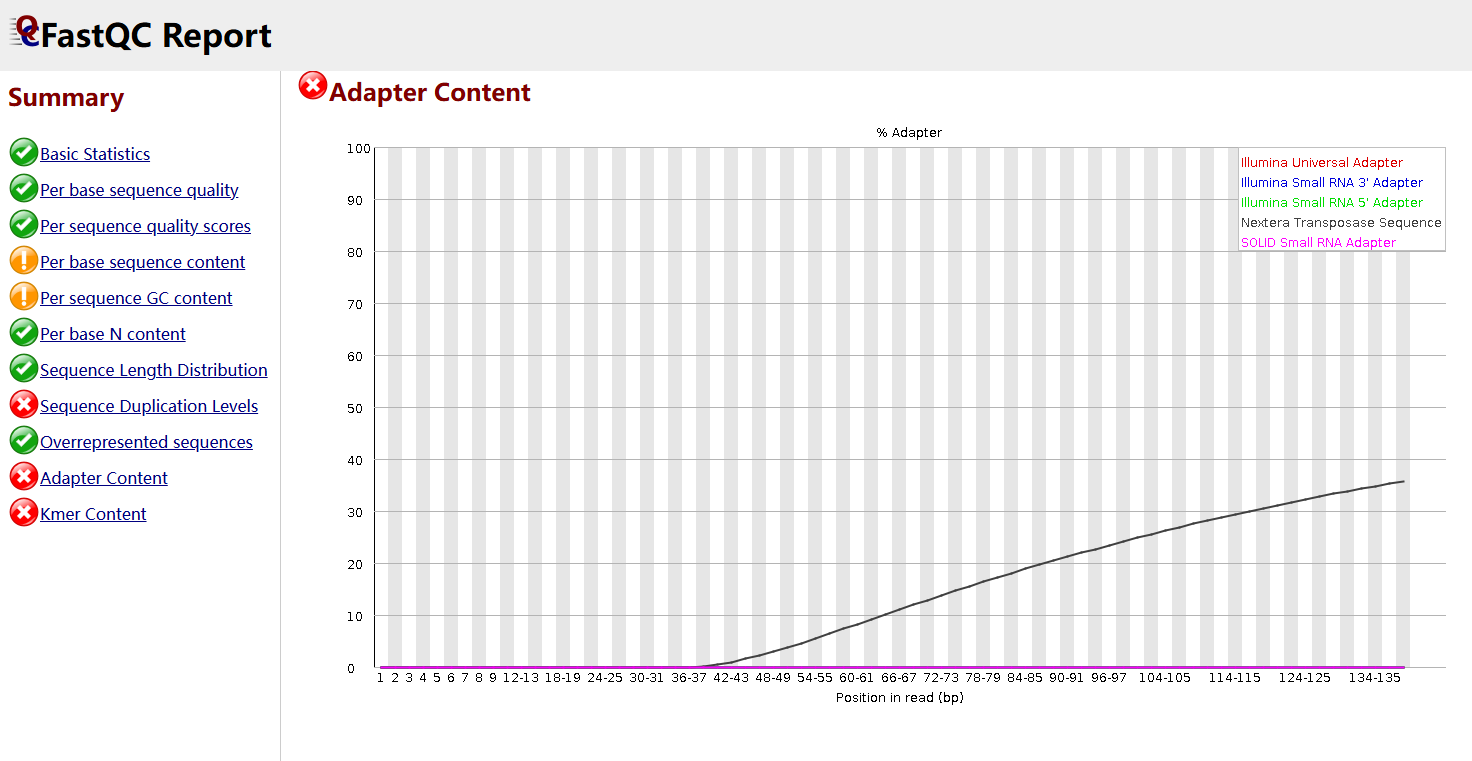

## Remove the adapters
You can use fastp, fastq-mcf, trimmomatic, cutadapt, etc. for this. We will illustrate [fastp](https://github.com/OpenGene/fastp) here which can automatically trim adapters, polyG tails, and do quality filtering.

In [10]:
mkdir -p ./data/03_trimmed_fastqc

In [15]:
# This automatically detects adapters but you can also provide a FASTA file of adapter sequences 
for SAMPLE in 2-cell 8-cell ICM hESC; do
    echo "Processing sample: $SAMPLE"
    fastp \
        -i ./data/01_fastq/${SAMPLE}_1.fastq \
        -I ./data/01_fastq/${SAMPLE}_2.fastq \
        -o ./data/03_trimmed_fastqc/${SAMPLE}_1_trimmed.fastq \
        -O ./data/03_trimmed_fastqc/${SAMPLE}_2_trimmed.fastq \
        --detect_adapter_for_pe \
        --thread 8 \
        --length_required 25 # reads shorter than this length will be discarded
done

echo "All samples have been processed. Trimmed files are in ./data/03_trimmed_fastqc"

Processing sample: 2-cell
Detecting adapter sequence for read1...
>I7_Nextera_Transposase_1 | >Trans2_rc | >I7_Nextera_Transposase_1 | >Trans2_rc
CTGTCTCTTATACACATCTCCGAGCCCACGAGAC

Detecting adapter sequence for read2...
>I5_Nextera_Transposase_1 | >Trans1_rc | >I5_Nextera_Transposase_1 | >Trans1_rc
CTGTCTCTTATACACATCTGACGCTGCCGACGA

Read1 before filtering:
total reads: 28216346
total bases: 4232451900
Q20 bases: 4073646199(96.2479%)
Q30 bases: 3910378366(92.3904%)

Read2 before filtering:
total reads: 28216346
total bases: 4232451900
Q20 bases: 3703982998(87.5139%)
Q30 bases: 3271849831(77.3039%)

Read1 after filtering:
total reads: 25528139
total bases: 3146298007
Q20 bases: 3106084972(98.7219%)
Q30 bases: 3029688127(96.2937%)

Read2 after filtering:
total reads: 25528139
total bases: 3144000586
Q20 bases: 2929532828(93.1785%)
Q30 bases: 2656372792(84.4902%)

Filtering result:
reads passed filter: 51056278
reads failed due to low quality: 5369832
reads failed due to too many N: 1448

### Let's check the QC again


In [16]:
#mkdir -p ./data/04_trimmed_qc

Due to time issues, we just select a 2-cell_1_trimmed.fastq file to check the qulity again. As we can see in the report below, the adapter content almost near to zero.

In [17]:
# Iterate over all FASTQ files in the ./data/01_fastq folder and run FastQC
for FASTQ_FILE in ./data/03_trimmed_fastqc/2-cell_1_trimmed.fastq; do
    echo "Running FastQC on $FASTQ_FILE"
    fastqc "$FASTQ_FILE" --outdir=./data/04_trimmed_qc --threads 8
done

echo "FastQC analysis completed. Results are saved in ./data/04_trimmed_qc"

Running FastQC on ./data/03_trimmed_fastqc/2-cell_1_trimmed.fastq
Started analysis of 2-cell_1_trimmed.fastq
Approx 5% complete for 2-cell_1_trimmed.fastq
Approx 10% complete for 2-cell_1_trimmed.fastq
Approx 15% complete for 2-cell_1_trimmed.fastq
Approx 20% complete for 2-cell_1_trimmed.fastq
Approx 25% complete for 2-cell_1_trimmed.fastq
Approx 30% complete for 2-cell_1_trimmed.fastq
Approx 35% complete for 2-cell_1_trimmed.fastq
Approx 40% complete for 2-cell_1_trimmed.fastq
Approx 45% complete for 2-cell_1_trimmed.fastq
Approx 50% complete for 2-cell_1_trimmed.fastq
Approx 55% complete for 2-cell_1_trimmed.fastq
Approx 60% complete for 2-cell_1_trimmed.fastq
Approx 65% complete for 2-cell_1_trimmed.fastq
Approx 70% complete for 2-cell_1_trimmed.fastq
Approx 75% complete for 2-cell_1_trimmed.fastq
Approx 80% complete for 2-cell_1_trimmed.fastq
Approx 85% complete for 2-cell_1_trimmed.fastq
Approx 90% complete for 2-cell_1_trimmed.fastq
Approx 95% complete for 2-cell_1_trimmed.fastq

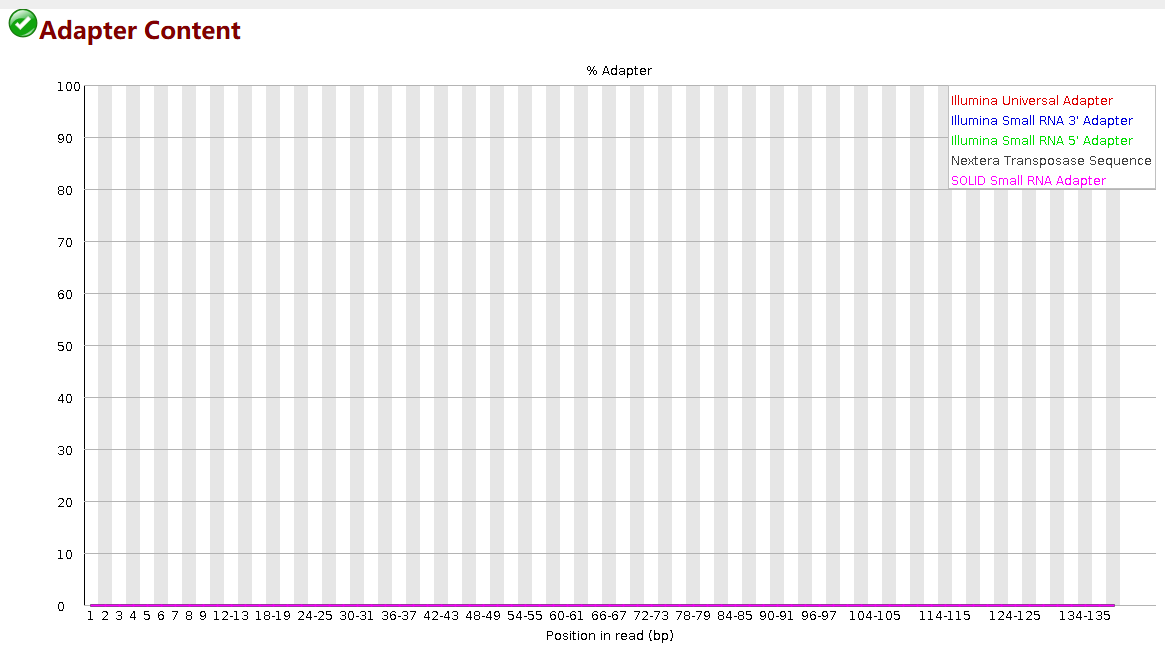
Ok, looks good now!

In [18]:
# Iterate over all FASTQ files and count the reads
for FASTQ_FILE in ./data/03_trimmed_fastqc/*.fastq; do
    # Count lines, divide by 4, and print the number of reads
    READ_COUNT=$(wc -l "$FASTQ_FILE" | awk '{ print $1/4 }')
    echo "File: $FASTQ_FILE - Reads: $READ_COUNT"
done

File: ./data/03_trimmed_fastqc/2-cell_1_trimmed.fastq - Reads: 25528139
File: ./data/03_trimmed_fastqc/2-cell_2_trimmed.fastq - Reads: 25528139
File: ./data/03_trimmed_fastqc/8-cell_1_trimmed.fastq - Reads: 15610480
File: ./data/03_trimmed_fastqc/8-cell_2_trimmed.fastq - Reads: 15610480
File: ./data/03_trimmed_fastqc/hESC_1_trimmed.fastq - Reads: 11587393
File: ./data/03_trimmed_fastqc/hESC_2_trimmed.fastq - Reads: 11587393
File: ./data/03_trimmed_fastqc/ICM_1_trimmed.fastq - Reads: 46540713
File: ./data/03_trimmed_fastqc/ICM_2_trimmed.fastq - Reads: 46540713


## Alignment of reads 
After retrieving and cleaning our fastq files, we can align them to our genome. To align the reads to the genome, we will use bowtie2. As reference genome, you can use the whole genome bowtie index at this location /mnt/storage/data/resources/bowtie2. 

According to paper, The paired-end ATAC-seq reads were aligned with the parameters: `-t -q -N 1 -L 25 -X 2000 –no-mixed –nodiscordant`. All unmapped reads, non-uniquely mapped reads and PCR duplicates were removed. 

In [25]:
# Create output directory for alignment results
mkdir -p ./data/05_alignment

Explanation of Parameters

`-t`: Prints the time taken for alignment (useful for performance tracking).

`-q`: Input files are in FASTQ format.

`-N 1`: Allows up to 1 mismatch in the seed alignment.

`-L 25`: Sets the seed length for alignment (25 bp).

`-X 2000`: Sets the maximum fragment length to 2000 bp (common for ATAC-seq).

`--no-mixed`: Disables reporting of unpaired reads in paired-end data.

`--no-discordant`: Disables reporting of discordant alignments (e.g., pairs mapped too far apart or in the wrong orientation).

In [9]:
# Loop through all samples for paired-end alignment
for SAMPLE in 2-cell 8-cell ICM hESC; do
    echo "Aligning $SAMPLE with Bowtie2"
    bowtie2 -p 16 -x /mnt/storage/data/resources/bowtie2/hg19 \
            -1 ./data/03_trimmed_fastqc/${SAMPLE}_1_trimmed.fastq \
            -2 ./data/03_trimmed_fastqc/${SAMPLE}_2_trimmed.fastq \
            -S ./data/05_alignment/${SAMPLE}.sam \
            -t -q -N 1 -L 25 -X 2000 --no-mixed --no-discordant
done

Aligning 2-cell with Bowtie2
Time loading reference: 00:00:00
Time loading forward index: 00:00:01
Time loading mirror index: 00:00:01
Multiseed full-index search: 00:42:25
25528139 reads; of these:
  25528139 (100.00%) were paired; of these:
    2449131 (9.59%) aligned concordantly 0 times
    9771203 (38.28%) aligned concordantly exactly 1 time
    13307805 (52.13%) aligned concordantly >1 times
90.41% overall alignment rate
Time searching: 00:42:28
Overall time: 00:42:28
Aligning 8-cell with Bowtie2
Time loading reference: 00:00:00
Time loading forward index: 00:00:01
Time loading mirror index: 00:00:01
Multiseed full-index search: 00:26:25
15610480 reads; of these:
  15610480 (100.00%) were paired; of these:
    1499470 (9.61%) aligned concordantly 0 times
    6643707 (42.56%) aligned concordantly exactly 1 time
    7467303 (47.84%) aligned concordantly >1 times
90.39% overall alignment rate
Time searching: 00:26:27
Overall time: 00:26:27
Aligning ICM with Bowtie2
Time loading refe

### Convert SAM to BAM 
Convert SAM files to BAM format, sort them, and remove duplicates.

In [17]:
head -500 ./data/05_alignment/2-cell.sam | tail -2

SRR5837316.481	83	chrM	13564	36	56M	=	13564	-56	ATCTATTACTCTCATCGCTACCTCCCTGACAAGCGCCTATAGCACTCGAATAATTC	JJJJJJFJJJJFJJJJJJJJ<7JJJJJJJJJJJJJJJJJJJJJJJJJJJJ-A-FAA	AS:i:0	XS:i:-22	XN:i:0	XM:i:0	XO:i:0	XG:i:0	NM:i:0	MD:Z:56	YS:i:0	YT:Z:CP
SRR5837316.481	163	chrM	13564	36	56M	=	13564	-56	ATCTATTACTCTCATCGCTACCTCCCTGACAAGCGCCTATAGCACTCGAATAATTC	-<AFFFJJJJJJJJJJJJJJJJJJJJJJJJJJAJFFFFJJJJFJJJJJJJJJJJJJ	AS:i:0	XS:i:-23	XN:i:0	XM:i:0	XO:i:0	XG:i:0	NM:i:0	MD:Z:56	YS:i:0	YT:Z:CP


In [58]:
for SAMPLE in 2-cell 8-cell ICM hESC; do
    echo "Converting $SAMPLE SAM to sorted BAM"
    # Step 1: Convert SAM to BAM
    samtools view -@ 8 -bS ./data/05_alignment/${SAMPLE}.sam -o ./data/05_alignment/${SAMPLE}.bam
    echo "$SAMPLE alignment and deduplication complete."
done

Converting 2-cell SAM to sorted BAM
2-cell alignment and deduplication complete.
Converting 8-cell SAM to sorted BAM
8-cell alignment and deduplication complete.
Converting ICM SAM to sorted BAM
ICM alignment and deduplication complete.
Converting hESC SAM to sorted BAM
hESC alignment and deduplication complete.


In [59]:
for SAMPLE in 2-cell 8-cell ICM hESC; do
    #step 1: 
    samtools view -c ./data/05_alignment/${SAMPLE}.bam
    samtools flags UNMAP,SECONDARY
    samtools view -@ 4 -c -F 260 ./data/05_alignment/${SAMPLE}.bam
    # Step 2: Sort by coordinate for markdup
    samtools sort -@ 8 -O bam -o ./data/05_alignment/${SAMPLE}_sorted.bam   ./data/05_alignment/${SAMPLE}.bam
    rm ./data/05_alignment/${SAMPLE}.bam  # Remove intermediate unsorted BAM file

    # Step 4: Index deduplicated BAM file
    samtools index -@ 8 ./data/05_alignment/${SAMPLE}_sorted.bam

done

51056278
0x104	260	UNMAP,SECONDARY
46158016
[bam_sort_core] merging from 16 files and 8 in-memory blocks...
31220960
0x104	260	UNMAP,SECONDARY
28222020
[bam_sort_core] merging from 8 files and 8 in-memory blocks...
93081426
0x104	260	UNMAP,SECONDARY
48641368
[bam_sort_core] merging from 24 files and 8 in-memory blocks...
23174786
0x104	260	UNMAP,SECONDARY
20303512
[bam_sort_core] merging from 8 files and 8 in-memory blocks...


### Filter Reads 
Remove unmapped and non-uniquely mapped reads from the deduplicated BAM file.

`-q 30`: Retains reads with a mapping quality (MAPQ) score of 30 or higher.

In [61]:
for SAMPLE in 2-cell 8-cell ICM hESC; do
    echo "Filtering unmapped and non-uniquely mapped reads for $SAMPLE"
    
    samtools view -@ 8 -b -q 30 ./data/05_alignment/${SAMPLE}_sorted.bam \
        > ./data/05_alignment/${SAMPLE}_filtered.bam
    # Index the filtered BAM file
    samtools index ./data/05_alignment/${SAMPLE}_filtered.bam
done


Filtering unmapped and non-uniquely mapped reads for 2-cell
Filtering unmapped and non-uniquely mapped reads for 8-cell
Filtering unmapped and non-uniquely mapped reads for ICM
Filtering unmapped and non-uniquely mapped reads for hESC


Now, these BAM files are sorted and indexed

In [70]:
for SAMPLE in 2-cell 8-cell ICM hESC; do
   
    rm ./data/05_alignment/${SAMPLE}_sorted.bam 
    rm ./data/05_alignment/${SAMPLE}_sorted.bam.bai
    rm ./data/05_alignment/${SAMPLE}_dedup.bam  
    rm ./data/05_alignment/${SAMPLE}_dedup.bam.bai

done

rm: cannot remove './data/05_alignment/2-cell_sorted.bam': No such file or directory
rm: cannot remove './data/05_alignment/2-cell_dedup.bam': No such file or directory
rm: cannot remove './data/05_alignment/2-cell_dedup.bam.bai': No such file or directory
rm: cannot remove './data/05_alignment/8-cell_sorted.bam': No such file or directory
rm: cannot remove './data/05_alignment/8-cell_dedup.bam': No such file or directory
rm: cannot remove './data/05_alignment/8-cell_dedup.bam.bai': No such file or directory
rm: cannot remove './data/05_alignment/ICM_sorted.bam': No such file or directory
rm: cannot remove './data/05_alignment/ICM_dedup.bam': No such file or directory
rm: cannot remove './data/05_alignment/ICM_dedup.bam.bai': No such file or directory
rm: cannot remove './data/05_alignment/hESC_sorted.bam': No such file or directory
rm: cannot remove './data/05_alignment/hESC_dedup.bam': No such file or directory
rm: cannot remove './data/05_alignment/hESC_dedup.bam.bai': No such file 

: 1

In [71]:
ls ./data/05_alignment

2-cell_alignment_stats.txt  8-cell_filtered.bam.bai   ICM_alignment_stats.txt
2-cell_filtered.bam         8-cell.sam                ICM_filtered.bam
2-cell_filtered.bam.bai     hESC_alignment_stats.txt  ICM_filtered.bam.bai
2-cell.sam                  hESC_filtered.bam         ICM.sam
8-cell_alignment_stats.txt  hESC_filtered.bam.bai
8-cell_filtered.bam         hESC.sam


### Alignment Quality Control 
#### 1. Alignment Statistics: Generate alignment statistics to confirm mapping efficiency 

In [63]:
for SAMPLE in 2-cell 8-cell ICM hESC; do
    samtools quickcheck ./data/05_alignment/${SAMPLE}_filtered.bam
    samtools flagstat ./data/05_alignment/${SAMPLE}_filtered.bam \
        > ./data/05_alignment/${SAMPLE}_alignment_stats.txt
done


In [64]:
cat ./data/05_alignment/2-cell_alignment_stats.txt

30221750 + 0 in total (QC-passed reads + QC-failed reads)
0 + 0 secondary
0 + 0 supplementary
0 + 0 duplicates
30221750 + 0 mapped (100.00% : N/A)
30221750 + 0 paired in sequencing
15110875 + 0 read1
15110875 + 0 read2
30221750 + 0 properly paired (100.00% : N/A)
30221750 + 0 with itself and mate mapped
0 + 0 singletons (0.00% : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


`30221750`: The total number of reads. `+ 0`: No reads failed the quality control.

`0 + 0 secondary`: No secondary alignments. Interpretation: All reads have a unique alignment position.

`0 + 0 supplementary`:No supplementary alignments. Interpretation: There are no soft-clipped or split alignments.

`15110875`: Number of read1 and read2, respectively.Interpretation: The data is paired-end sequencing, and all reads have their respective pairs.

`0 + 0 with mate mapped to a different chr`:0: No paired reads are mapped to different chromosomes.Interpretation: All paired reads are mapped within the same chromosome.

To sum up, the mapping rate is 100%, with no secondary or supplementary alignments, and all reads are properly paired.This is an exceptionally high-quality ATAC-seq alignment result.

#### 2. Inspect Read Distribution: Visualize aligned reads using a genome browser like IGV 
Now you can download the bam and the index (bam.bai) file to visualize your results in IGV. The chromatin accessibility profiles for the two-cell, eight-cell, ICM, and hESC stages were visualized using Integrative Genomics Viewer (IGV). BAM files and their respective indices were used for mapping open chromatin regions at specific genomic loci. 

According to paper, key loci investigated included `DUX4`, a transcription factor critical for minor ZGA, and `GSC`, `PITX1`, `TFAP2C`, and `GATA`, which play prominent roles in major ZGA and subsequent developmental stages.

Figure 1: Chromatin accessibility at GSC locus across two-cell, eight-cell, ICM, and hESC stages. Open chromatin regions align with the transcriptional activity associated with major ZGA.

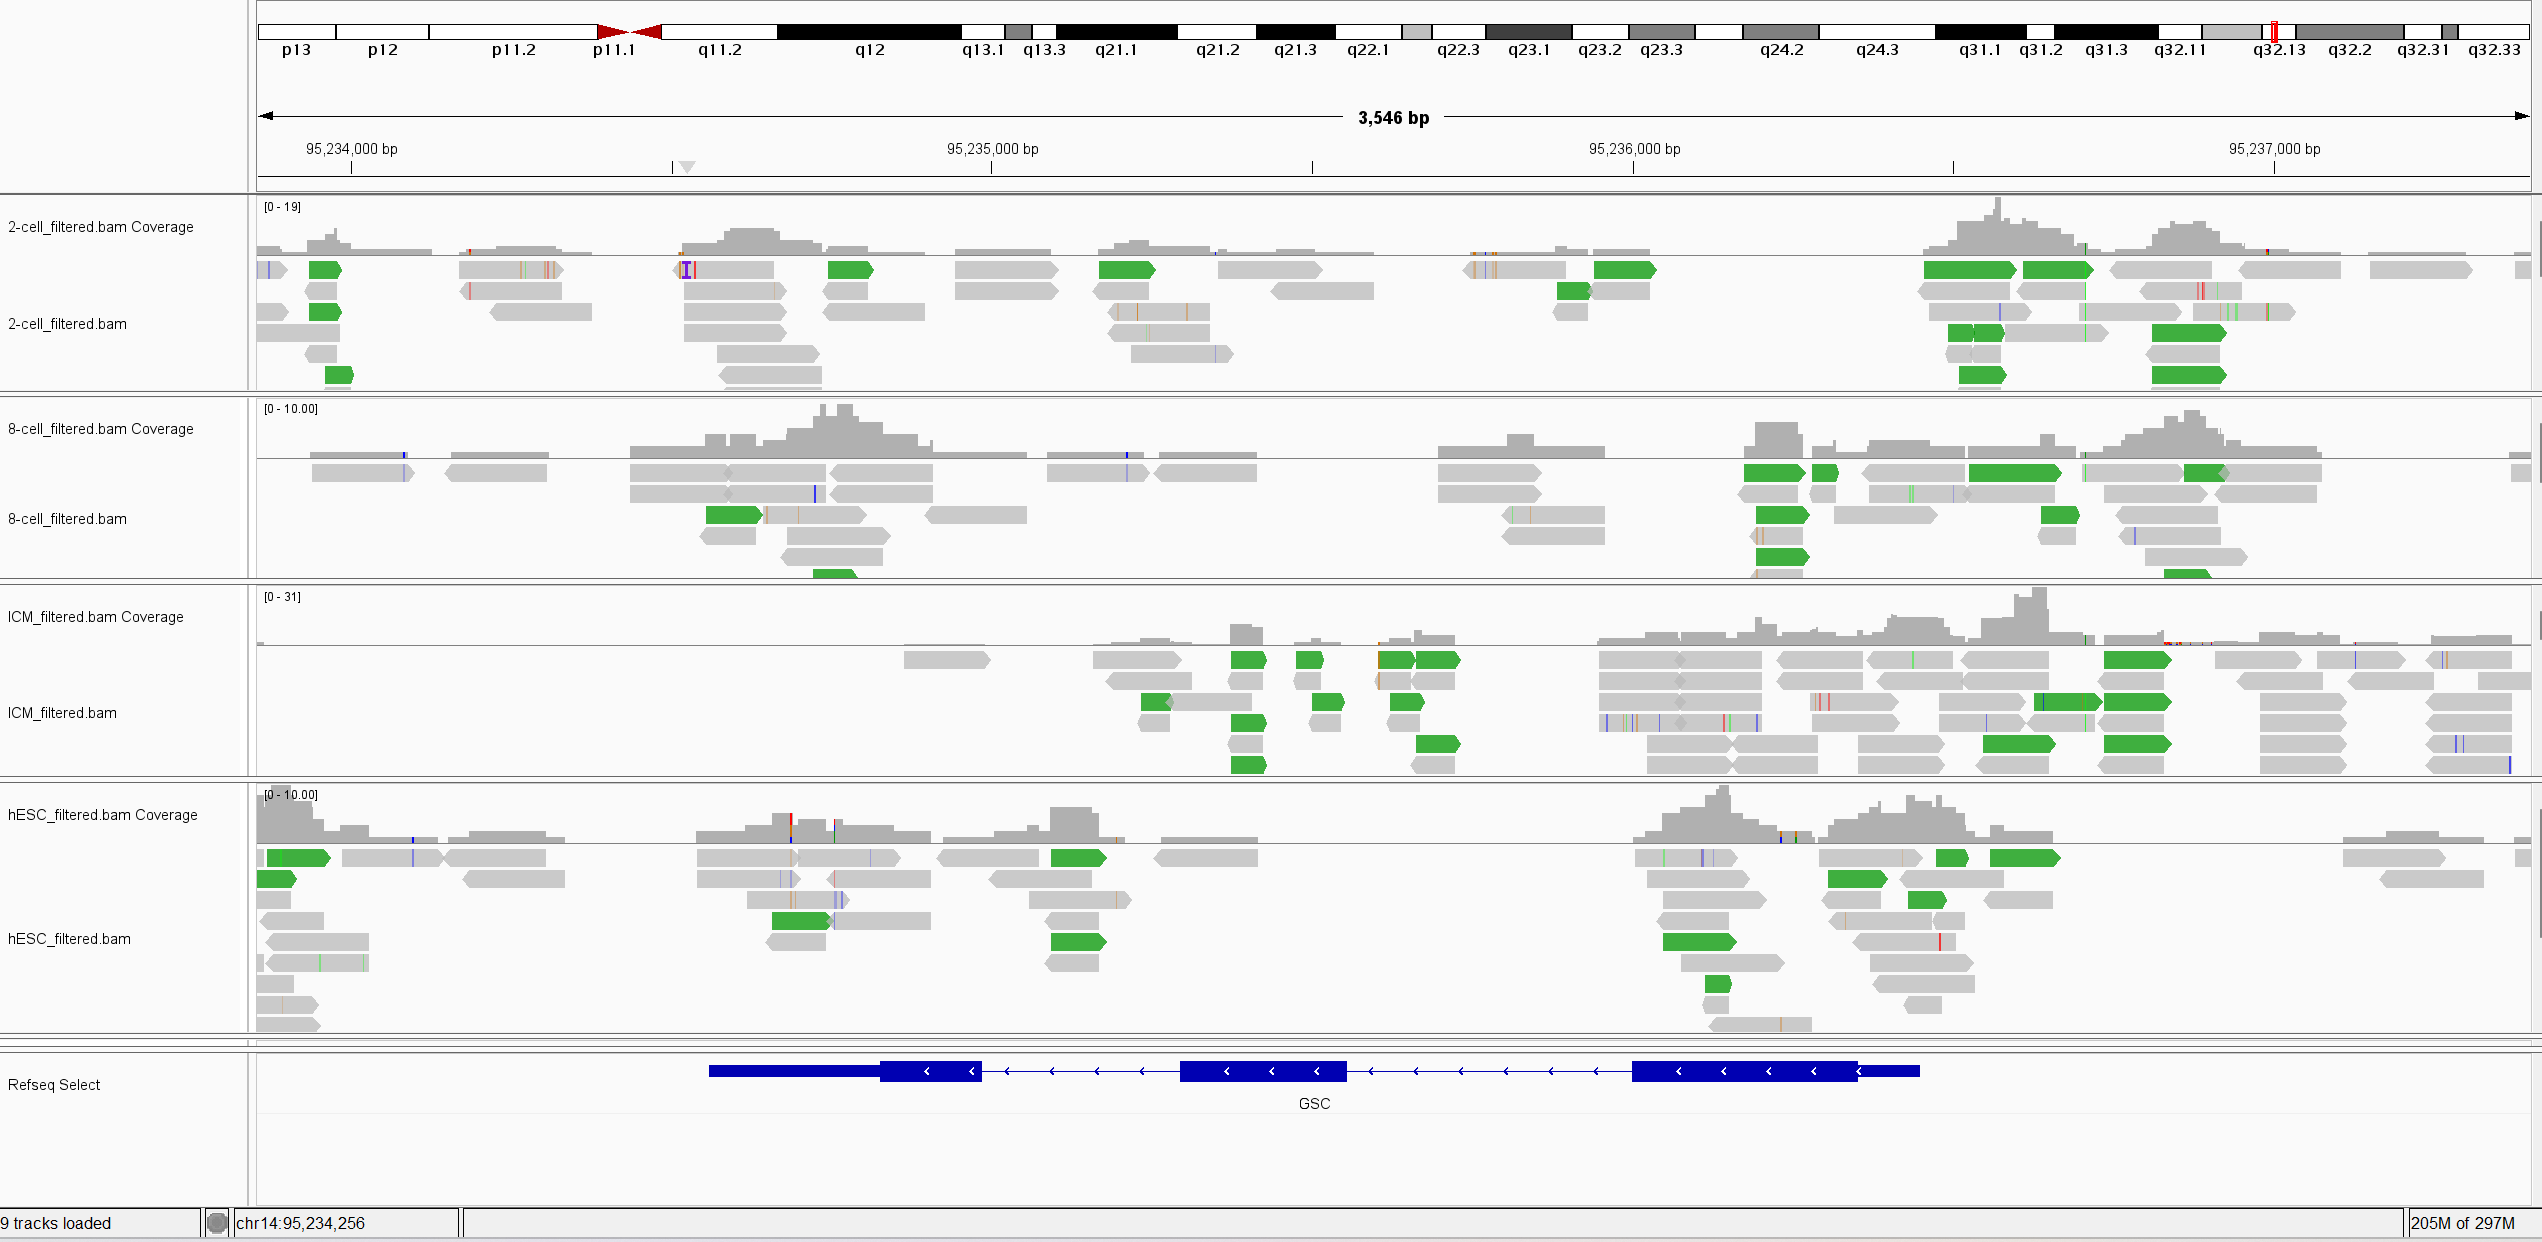

Figure 2: Chromatin accessibility at PITX1 locus, showing increased accessibility from eight-cell to hESC stages, consistent with its role in early developmental regulation.

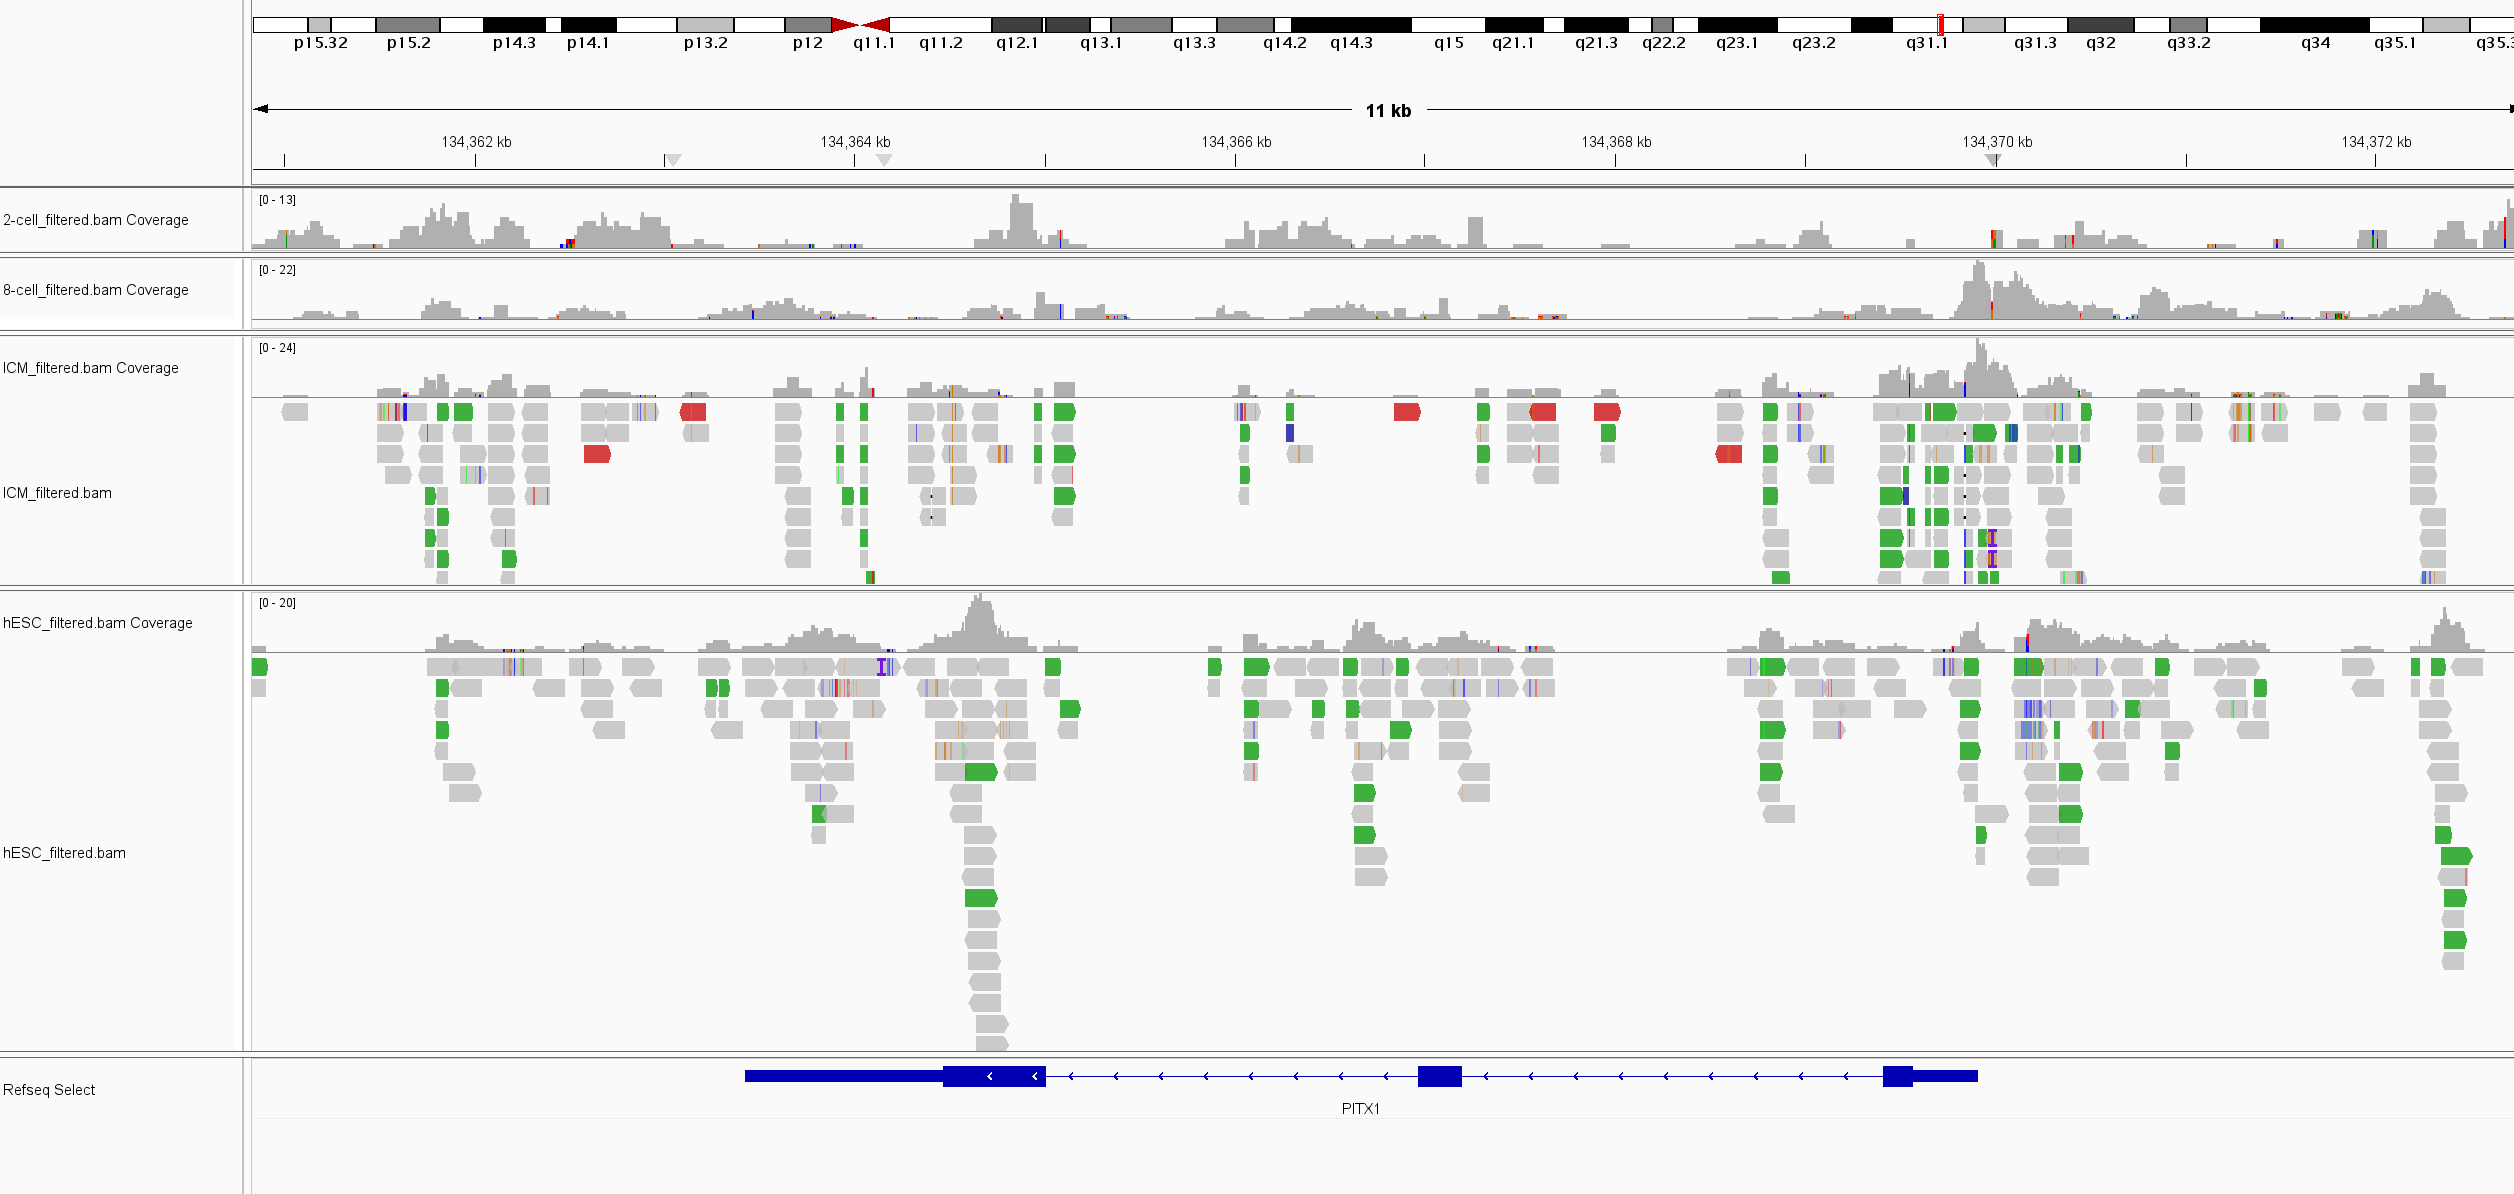

### Genome Coverage 
Genome coverage results in statistics and visualizations of the coverage at each location on the genome. It reflects the distribution of sequencing data across the genome and can help assess data quality and signal characteristics.

we normalized the read counts by computing the numbers of reads per kilobase of bin per million of reads sequenced (RPKM). RPKM values were averaged for each bin between replicates. To minimize the batch and cell type variation, the RPKM values were further normalized by Z-score transformation. To visualize the ATAC-seq signal in the UCSC genome browser, we extended each read by 250 base pairs (bp) and counted the coverage for each base.

`--binSize 10`: Divides the genome into bins of 10 bp for calculating coverage. Smaller bins result in higher resolution but larger file sizes.

`--normalizeUsing RPKM`: Normalizes coverage to Reads Per Kilobase per Million mapped reads (RPKM)

`--extendReads 250`: Extends reads to a length of 250 bp, simulating fragment lengths.

`--effectiveGenomeSize 2913022398`: Specifies the effective mappable genome size for normalization (based on `hg19`/human genome without repetitive regions)

`--ignoreDuplicates`: Ignores duplicate reads (e.g., PCR artifacts).

In [75]:
for BAM in ./data/05_alignment/*_filtered.bam; do
    BASE=$(basename $BAM .bam) 
    bamCoverage \
        -b $BAM \
        -o ./data/05_alignment/${BASE}.bw \
        --binSize 10 \
        --normalizeUsing RPKM \
        --extendReads 250 \
        --effectiveGenomeSize 2913022398 \
        --ignoreDuplicates
done

normalization: RPKM
bamFilesList: ['./data/05_alignment/2-cell_filtered.bam']
binLength: 10
numberOfSamples: None
blackListFileName: None
skipZeroOverZero: False
bed_and_bin: False
defaultFragmentLength: 250
numberOfProcessors: 1
verbose: False
region: None
bedFile: None
minMappingQuality: None
ignoreDuplicates: True
chrsToSkip: []
stepSize: 10
center_read: False
samFlag_include: None
samFlag_exclude: None
minFragmentLength: 0
maxFragmentLength: 0
zerosToNans: False
smoothLength: None
save_data: False
out_file_for_raw_data: None
maxPairedFragmentLength: 1000
normalization: RPKM
bamFilesList: ['./data/05_alignment/8-cell_filtered.bam']
binLength: 10
numberOfSamples: None
blackListFileName: None
skipZeroOverZero: False
bed_and_bin: False
defaultFragmentLength: 250
numberOfProcessors: 1
verbose: False
region: None
bedFile: None
minMappingQuality: None
ignoreDuplicates: True
chrsToSkip: []
stepSize: 10
center_read: False
samFlag_include: None
samFlag_exclude: None
minFragmentLength: 0
maxF

In [76]:
ls ./data/05_alignment/*.bw

./data/05_alignment/2-cell_filtered.bw  ./data/05_alignment/hESC_filtered.bw
./data/05_alignment/8-cell_filtered.bw  ./data/05_alignment/ICM_filtered.bw


#### Heatmap plot 

Heatmap are plotted with 800 bases wide on both side. As from the heatmap, the strength (height) of the peaks is not very strong, indicating a weak signal.
We will use the deeptools commands to generate a heatmap, see here for more info: https://deeptools.readthedocs.io/en/develop/content/tools/plotHeatmap.html

TSS enrichment analysis
ATAC-seq data should show significant signal enrichment near the transcription initiation site (TSS).

In [10]:
mkdir -p ./data/07_TSS

In [3]:
awk '{if ($6 == "+") print $1, $2, $2+1, $4, 0, $6; else print $1, $3-1, $3, $4, 0, $6}' ./data/TSS> ./data/tss.bed

In [5]:
head ./data/tss.bed

chr1 11868 11869 ENST00000456328.2_1 0 +
chr1 12009 12010 ENST00000450305.2_2 0 +
chr1 24885 24886 ENST00000488147.2_5 0 -
chr1 29553 29554 ENST00000473358.1_5 0 +
chr1 30266 30267 ENST00000469289.1_1 0 +
chr1 36080 36081 ENST00000417324.1_4 0 -
chr1 36072 36073 ENST00000461467.1_3 0 -
chr1 52472 52473 ENST00000606857.1_2 0 +
chr1 57597 57598 ENST00000642116.1_2 0 +
chr1 62948 62949 ENST00000492842.2_3 0 +


In [8]:
awk '{$1=$1}1' OFS='\t' ./data/tss.bed > ./data/tss_fixed.bed

In [2]:
computeMatrix reference-point \
    -S ./data/05_alignment/2-cell_filtered.bw \
       ./data/05_alignment/8-cell_filtered.bw \
       ./data/05_alignment/ICM_filtered.bw \
       ./data/05_alignment/hESC_filtered.bw \
    -R ./data/tss_fixed.bed \
    --referencePoint TSS \
    -a 2000 -b 2000 \
    -out ./data/07_TSS/TSS.tab.gz \
    --binSize 50\
    --numberOfProcessors 8

Skipping ENST00000387314.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000389680.2_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387342.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387347.2_r1, due to being absent in the computeMatrix output.
Skipping ENST00000386347.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000361390.2_2_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387365.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387372.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387377.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000361453.3_2_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387382.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387392.1_r1, due to being absent in the computeMatrix output.
Skipping ENST00000387400.1_r1, due t

In [3]:
plotHeatmap \
    -m ./data/07_TSS/TSS.tab.gz \
    -out ./data/07_TSS/all-peaks-ATAC.png \
    --heatmapHeight 15 \
    --refPointLabel "TSS" \
    --regionsLabel "Peaks" \
    --samplesLabel "2-cell" "8-cell" "ICM" "hESC" \
    --plotTitle "ATAC-seq Signal"

/usr/local/lib/python3.6/dist-packages/deeptools/plotHeatmap.py:452: MatplotlibDeprecationWarning:

You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("RdYlBu"))

/usr/local/lib/python3.6/dist-packages/deeptools/plotHeatmap.py:721: MatplotlibDeprecationWarning:

The 'alpha' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.

/usr/local/lib/python3.6/dist-packages/deeptools/plotHeatmap.py:729: MatplotlibDeprecationWarning:

savefig() got unexpected keyword argument "pdd_inches" which is no longer supported as of 3.3 and will become an error two minor releases later



In [4]:
ls -lt ./data/07_TSS/all-peaks-ATAC.png

-rw-r--r-- 1 r0880433 domain users 708646 Jan  5 11:36 ./data/07_TSS/all-peaks-ATAC.png


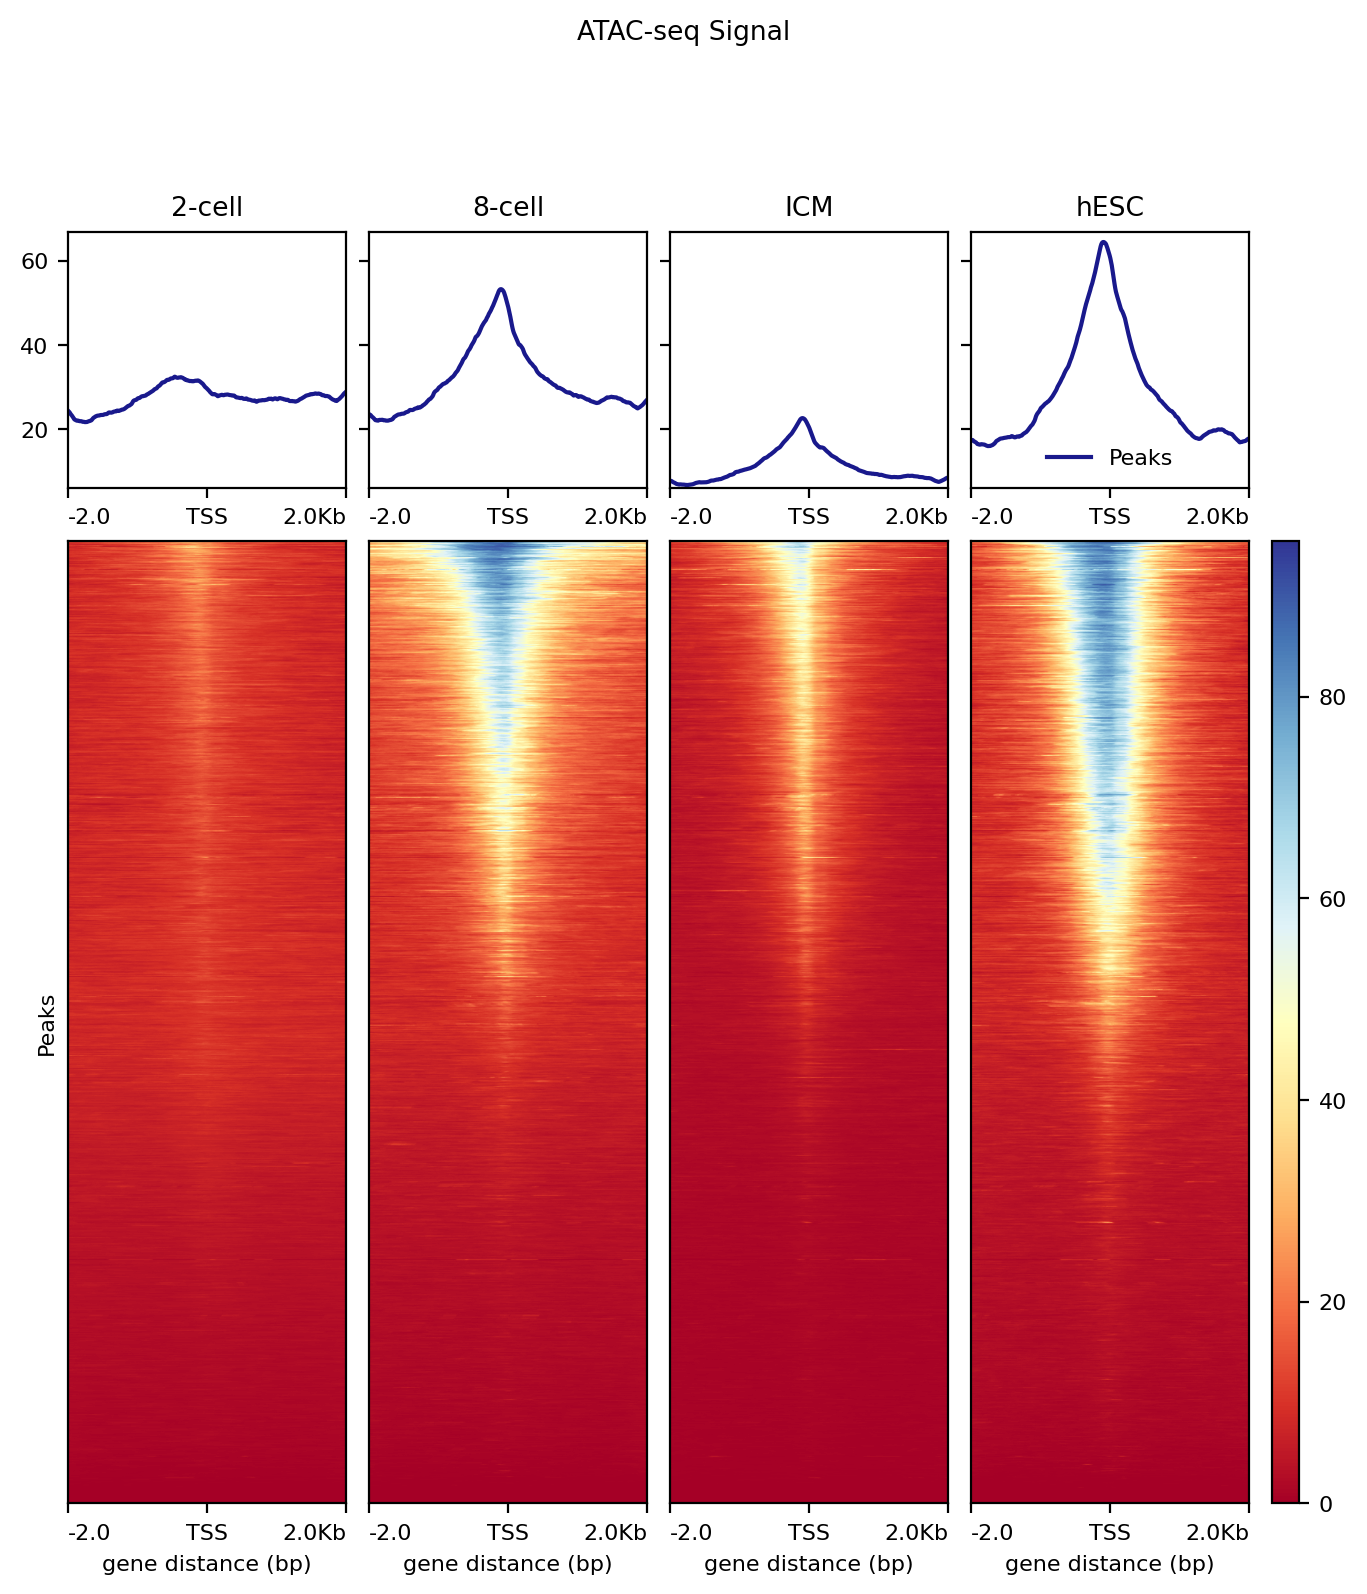

`2-cell stage`: chromatin is relatively closed and gene expression is low, which is in line with the state of early embryonic development.

`8-cell stage`: Increased chromatin openness indicates that the genome is gradually activated during embryonic development to prepare for subsequent gene expression.

`ICM stage`: The inner cell mass is an important stage of embryonic development, when gene expression tends to be specialized and chromatin openness remains at a medium-high level.

`hESC stage`: Embryonic stem cells are pluripotent, with more extensive areas of open chromatin, supporting them to maintain differentiation potential and high transcriptional activity.

## Peak Calling using MACS2 
`macs2` algorithm is used to determine and locate peaks in the datasets, with size of human genome (as in `bamCoverage` algorithm) and a cut-off of 0.05

In [77]:
mkdir -p ./data/06_peaks  

In [5]:
for BAM in ./data/05_alignment/*_filtered.bam; do
    SAMPLE=$(basename $BAM _filtered.bam)

    # Call peaks using MACS2
    macs2 callpeak -B \
        -t $BAM \
        -g hs \
        -n ${SAMPLE}_peaks \
        --outdir ./data/06_peaks \
        --nomodel \
        --extsize 250 \
        -q 0.01
done

INFO  @ Sun, 05 Jan 2025 11:59:43: 
# Command line: callpeak -B -t ./data/05_alignment/2-cell_filtered.bam -g hs -n 2-cell_peaks --outdir ./data/06_peaks --nomodel --extsize 250 -q 0.01
# ARGUMENTS LIST:
# name = 2-cell_peaks
# format = AUTO
# ChIP-seq file = ['./data/05_alignment/2-cell_filtered.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 1.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
 
INFO  @ Sun, 05 Jan 2025 11:59:43: #1 read tag files... 
INFO  @ Sun, 05 Jan 2025 11:59:43: #1 read treatment tags... 
INFO  @ Sun, 05 Jan 2025 11:59:43: Detected format is: BAM 
INFO  @ Sun, 05 Jan 2025 11:59:43: * Input file is gzipped

# ChIP-seq file = ['./data/05_alignment/hESC_filtered.bam']
# control file = None
# effective genome size = 2.70e+09
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 1.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 10000 bps
# Broad region calling is off
# Paired-End mode is off
 
INFO  @ Sun, 05 Jan 2025 12:17:49: #1 read tag files... 
INFO  @ Sun, 05 Jan 2025 12:17:49: #1 read treatment tags... 
INFO  @ Sun, 05 Jan 2025 12:17:49: Detected format is: BAM 
INFO  @ Sun, 05 Jan 2025 12:17:49: * Input file is gzipped. 
INFO  @ Sun, 05 Jan 2025 12:17:55:  1000000 
INFO  @ Sun, 05 Jan 2025 12:18:01:  2000000 
INFO  @ Sun, 05 Jan 2025 12:18:09:  3000000 
INFO  @ Sun, 05 Jan 2025 12:18:16:  4000000 
INFO  @ Sun, 05 Jan 2025 12:18:21:  5000000 
INFO  @ Sun, 05 

In [6]:
ls -lt ./data/06_peaks/*.bed 
ls -lt ./data/06_peaks/*.bdg 

-rw-r--r-- 1 r0880433 domain users  958092 Jan  5 12:30 ./data/06_peaks/ICM_peaks_summits.bed
-rw-r--r-- 1 r0880433 domain users 1500252 Jan  5 12:22 ./data/06_peaks/hESC_peaks_summits.bed
-rw-r--r-- 1 r0880433 domain users  846081 Jan  5 12:17 ./data/06_peaks/8-cell_peaks_summits.bed
-rw-r--r-- 1 r0880433 domain users   23351 Jan  5 12:07 ./data/06_peaks/2-cell_peaks_summits.bed
-rw-r--r-- 1 r0880433 domain users 147269002 Jan  5 12:30 ./data/06_peaks/ICM_peaks_control_lambda.bdg
-rw-r--r-- 1 r0880433 domain users 257763971 Jan  5 12:30 ./data/06_peaks/ICM_peaks_treat_pileup.bdg
-rw-r--r-- 1 r0880433 domain users 136498503 Jan  5 12:22 ./data/06_peaks/hESC_peaks_control_lambda.bdg
-rw-r--r-- 1 r0880433 domain users 241813805 Jan  5 12:22 ./data/06_peaks/hESC_peaks_treat_pileup.bdg
-rw-r--r-- 1 r0880433 domain users 147499586 Jan  5 12:17 ./data/06_peaks/8-cell_peaks_control_lambda.bdg
-rw-r--r-- 1 r0880433 domain users 244604282 Jan  5 12:17 ./data/06_peaks/8-cell_peaks_treat_pileup.b

In [5]:
cat ./data/06_peaks/2-cell_peaks_peaks.narrowPeak | sort -k 5,5gr  | head -10

chr2	149639103	149639563	2-cell_peaks_peak_249	953	.	23.55828	104.48471	95.32301	227
chr1	569697	570159	2-cell_peaks_peak_3	744	.	13.50820	82.26225	74.43372	228
chr7	61968762	61969634	2-cell_peaks_peak_373	650	.	13.91304	72.63802	65.05521	219
chr6	58778148	58779408	2-cell_peaks_peak_353	622	.	6.28099	69.56784	62.21327	911
chr1	121484464	121485531	2-cell_peaks_peak_20	594	.	12.46377	66.62289	59.48184	528
chr1	568048	568474	2-cell_peaks_peak_2	530	.	10.83871	59.75446	53.04921	208
chr5	134259832	134260486	2-cell_peaks_peak_332	519	.	13.86935	58.58000	51.90970	436
chrUn_gl000220	143999	144718	2-cell_peaks_peak_420	311	.	2.89812	37.20366	31.11100	359
chrM	14328	16506	2-cell_peaks_peak_410	260	.	1.78197	31.95786	26.04783	1208
chrUn_gl000224	3628	4565	2-cell_peaks_peak_422	250	.	7.90698	30.95336	25.07027	307
sort: write failed: 'standard output': Broken pipe
sort: write error


The increasing of numbers of peaks highlight the dynamic nature of chromatin accessibility during preimplantation development.

In [7]:
cat ./data/06_peaks/2-cell_peaks_peaks.narrowPeak | wc -l
cat ./data/06_peaks/8-cell_peaks_peaks.narrowPeak | wc -l

434
15269


### Find differential ATAC-seq signal, genome-wide 


In [12]:
egrep "tags after filtering in treatment|tags after filtering in control" ./data/06_peaks/8-cell_peaks_peaks.xls
egrep "tags after filtering in treatment|tags after filtering in control" ./data/06_peaks/2-cell_peaks_peaks.xls

# tags after filtering in treatment: 3898925
# tags after filtering in treatment: 4770086


In [13]:
macs2 bdgdiff \
    --t1 ./data/06_peaks/8-cell_peaks_treat_pileup.bdg \
    --c1 ./data/06_peaks/8-cell_peaks_control_lambda.bdg \
    --t2 ./data/06_peaks/2-cell_peaks_treat_pileup.bdg \
    --c2 ./data/06_peaks/2-cell_peaks_control_lambda.bdg \
    --d1 3898925 \
    --d2 4770086 \
    -g 60 \
    -l 120 \
    -C 3 \
    --o-prefix diff_2-cell_vs_8-cell

INFO  @ Sun, 05 Jan 2025 12:54:22: Read and build treatment 1 bedGraph... 
INFO  @ Sun, 05 Jan 2025 12:54:37: Read and build control 1 bedGraph... 
INFO  @ Sun, 05 Jan 2025 12:54:48: Read and build treatment 2 bedGraph... 
INFO  @ Sun, 05 Jan 2025 12:55:08: Read and build control 2 bedGraph... 
INFO  @ Sun, 05 Jan 2025 12:56:56: Write peaks... 
INFO  @ Sun, 05 Jan 2025 12:56:56: Done 


In [16]:
wc -l *.bed

    687 diff_2-cell_vs_8-cell_c3.0_common.bed
  16859 diff_2-cell_vs_8-cell_c3.0_cond1.bed
    675 diff_2-cell_vs_8-cell_c3.0_cond2.bed
      0 TSS_regions.bed
  18221 total


In [17]:
cat diff_2-cell_vs_8-cell_c3.0_cond1.bed | sort -k 5,5gr | head

chrUn_gl000220	117667	119114	diff_2-cell_vs_3-cell_cond1_16350	101.52783
chr11	33277386	33277816	diff_2-cell_vs_3-cell_cond1_2570	75.09660
chr7	150711322	150711567	diff_2-cell_vs_3-cell_cond1_15006	74.55293
chr11	62607843	62608645	diff_2-cell_vs_3-cell_cond1_2726	73.08358
chr19	44098452	44098812	diff_2-cell_vs_3-cell_cond1_8279	71.60457
chr8	103876216	103876545	diff_2-cell_vs_3-cell_cond1_15503	70.31324
chr10	99326232	99326510	diff_2-cell_vs_3-cell_cond1_2207	69.56089
chr10	43930889	43931308	diff_2-cell_vs_3-cell_cond1_1919	66.94279
chr1	35664518	35665026	diff_2-cell_vs_3-cell_cond1_412	66.51658
chr10	70283577	70283748	diff_2-cell_vs_3-cell_cond1_1997	65.79115
sort: write failed: 'standard output': Broken pipe
sort: write error


The IGV visualization highlights the chromatin accessibility at the PITX1 locus across the 2-cell and 8-cell stages.The observed difference in chromatin accessibility demonstrates that PITX1 plays a role in transcriptional regulation after ZGA, likely contributing to developmental processes such as lineage specification.

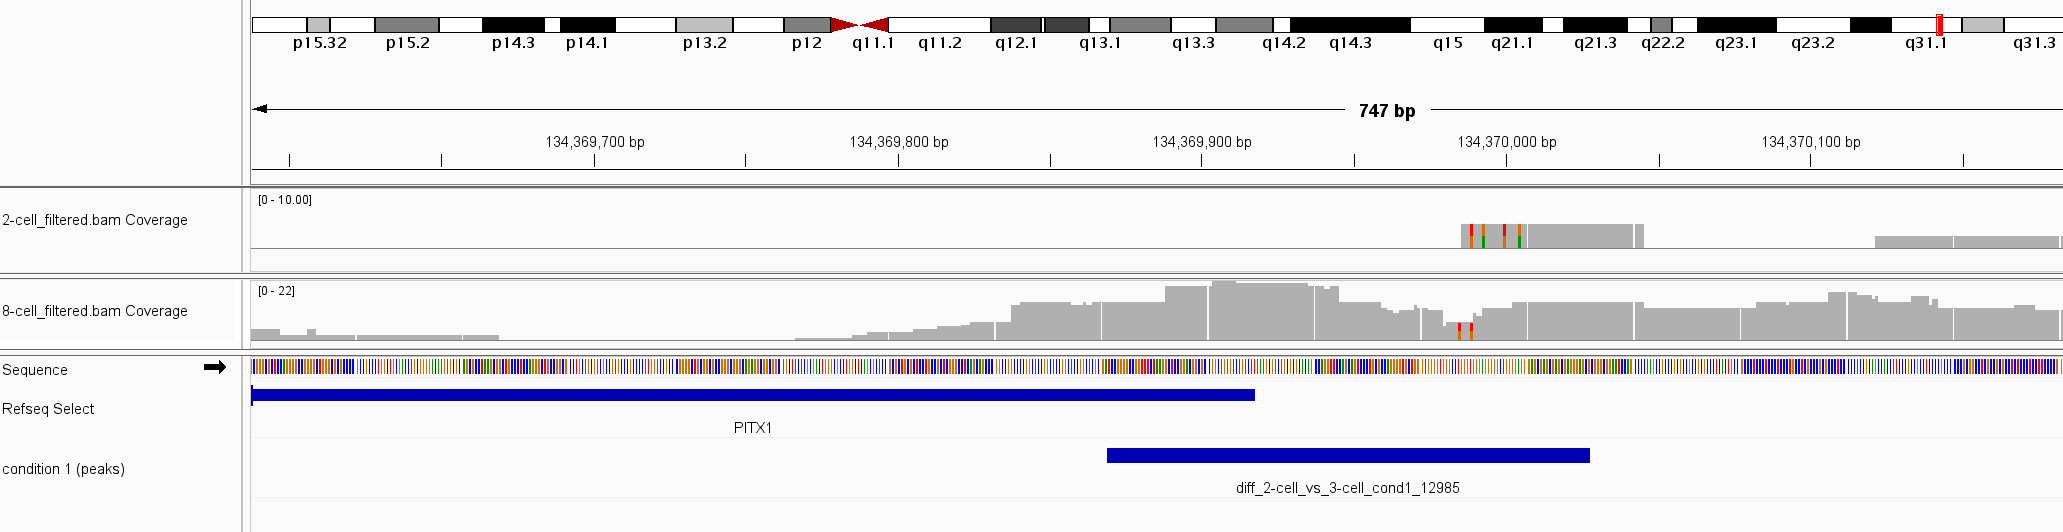

## motif discovery
Run RSAT peak-motifs at the RSAT website https://rsat.france-bioinformatique.fr/teaching/

Here is a tutorial for RSAT peak-motifs: https://rsat.france-bioinformatique.fr/teaching/tutorials/tut_peak-motifs.html

Background information about position-specific scoring matrices (PSSM) is here: https://rsat.france-bioinformatique.fr/teaching/tutorials/tut_PSSM.html

Before running peak-motifs, you need as input the <b>FASTA sequences of the peaks</b>. How to get these?
Some options: 

1. Use retrieve sequences from BED format in RSAT https://rsat.france-bioinformatique.fr/teaching/retrieve-seq-bed_form.cgi (or fetch-sequences from UCSC https://rsat.france-bioinformatique.fr/teaching/fetch-sequences_form.php).
2. Use MEME suite BED2FASTA tool https://meme-suite.org/meme/tools/bed2fasta.
3. UCSC Table Browser (first make a custom track of your peak BED file)
4. Command-line (e.g., using BEDTools: bedtools getfasta -fi 'genome FASTA' -bed 'input BED')

In [18]:
mkdir -p ./data/08_motif

In [19]:
bedtools getfasta -fi /mnt/storage/data/resources/hg19/hg19.fa -bed diff_2-cell_vs_8-cell_c3.0_cond1.bed -fo ./data/08_motif/differential_regions.fasta

WARNING. chromosome (chr17_gl000205_random) was not found in the FASTA file. Skipping.
WARNING. chromosome (chr17_gl000205_random) was not found in the FASTA file. Skipping.
WARNING. chromosome (chr1_gl000192_random) was not found in the FASTA file. Skipping.
WARNING. chromosome (chr4_gl000193_random) was not found in the FASTA file. Skipping.
WARNING. chromosome (chr7_gl000195_random) was not found in the FASTA file. Skipping.
WARNING. chromosome (chr7_gl000195_random) was not found in the FASTA file. Skipping.
WARNING. chromosome (chrUn_gl000211) was not found in the FASTA file. Skipping.
WARNING. chromosome (chrUn_gl000212) was not found in the FASTA file. Skipping.
WARNING. chromosome (chrUn_gl000220) was not found in the FASTA file. Skipping.
WARNING. chromosome (chrUn_gl000220) was not found in the FASTA file. Skipping.
WARNING. chromosome (chrUn_gl000220) was not found in the FASTA file. Skipping.
WARNING. chromosome (chrUn_gl000220) was not found in the FASTA file. Skipping.
WA

### RSAT peak-motifs


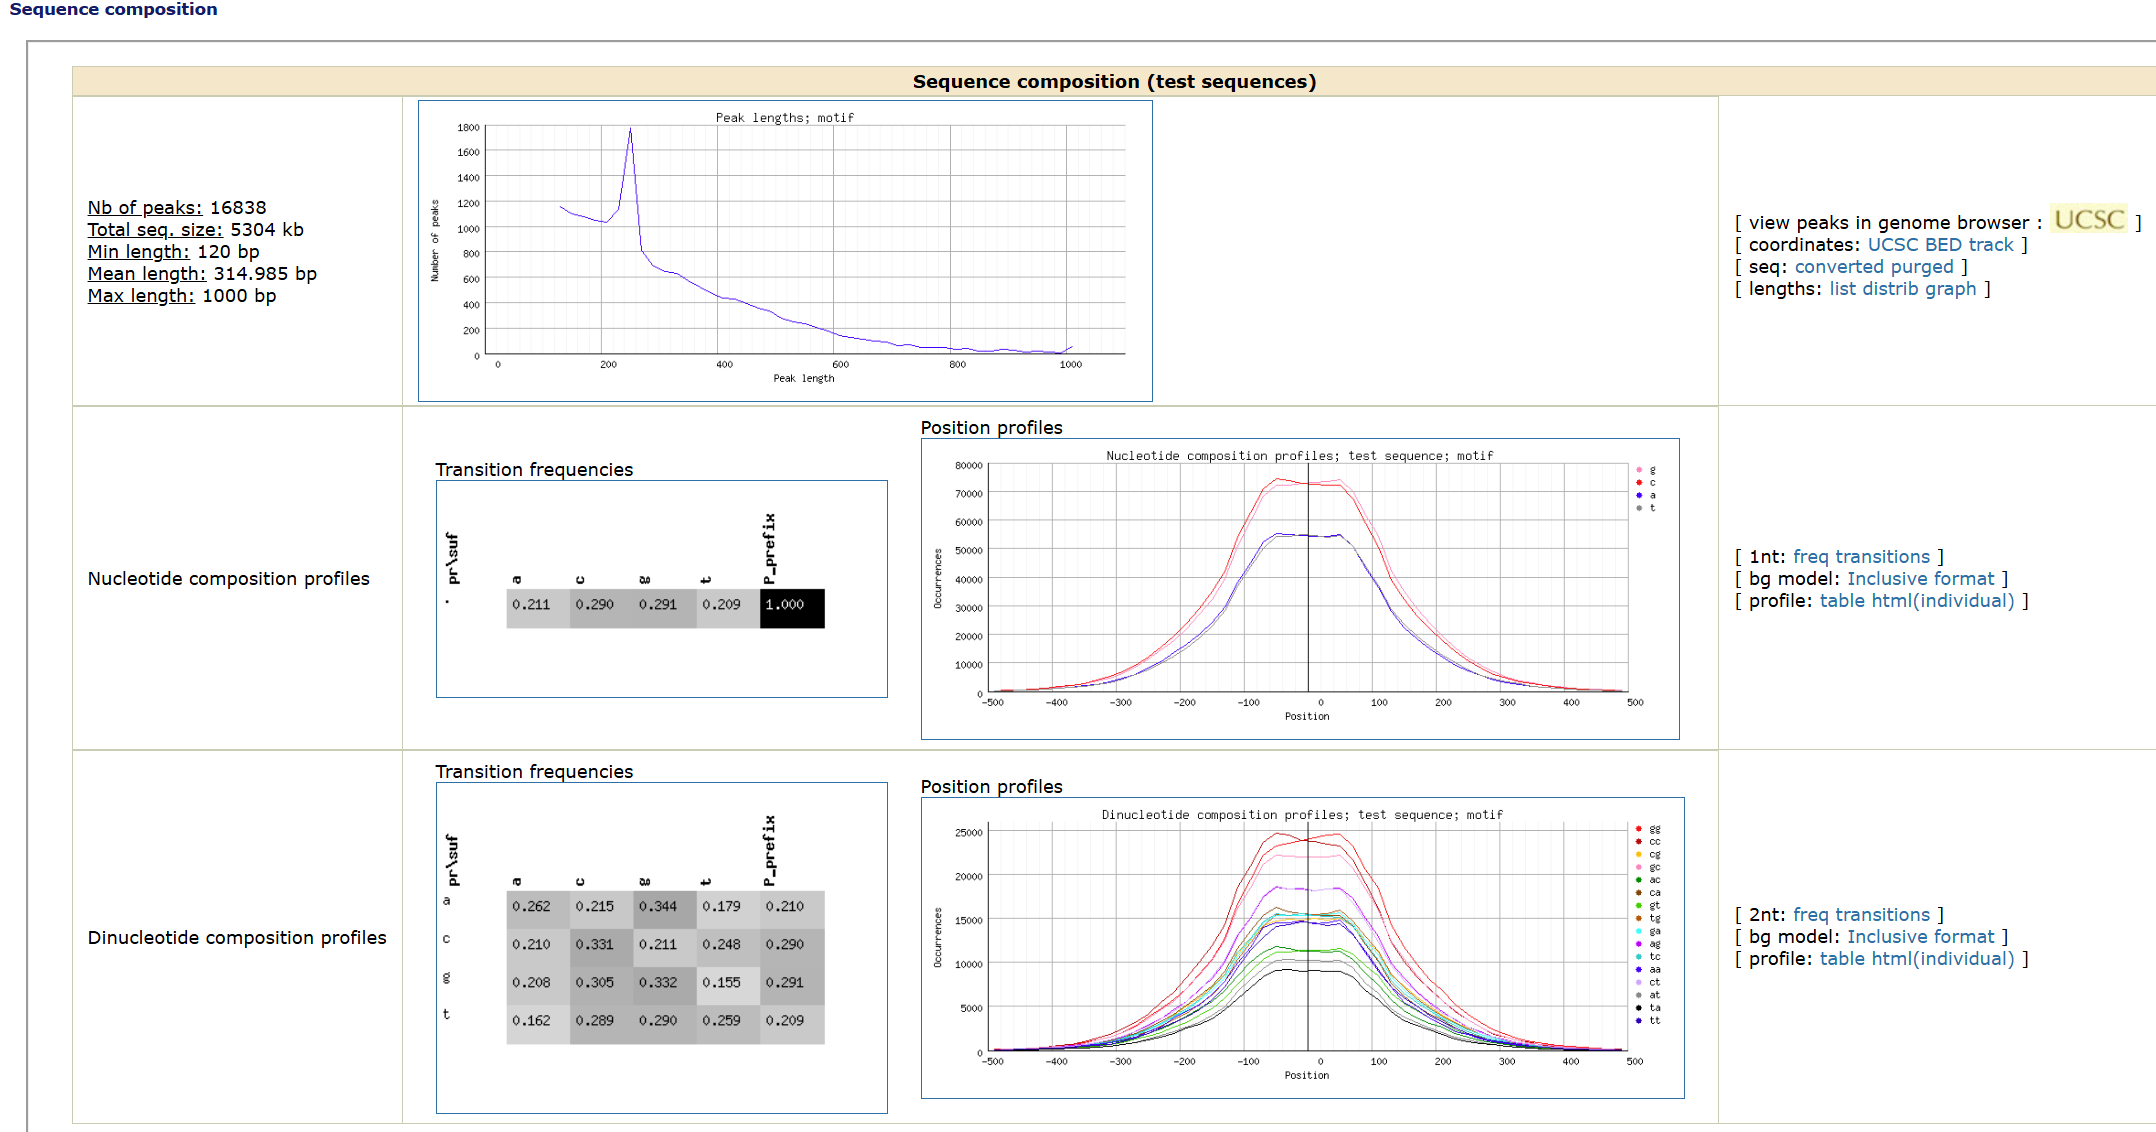

This analysis([report](https://rsat.france-bioinformatique.fr/teaching/tmp/www-data/2025/01/05/peak-motifs.2025-01-05.133208_2025-01-05.133208_DfDQfq/peak-motifs_synthesis.html)) provides insight into the chromatin accessibility and its changes during preimplantation development, particularly in the transition from the `2-cell stage (before ZGA)` to the `8-cell stage (after ZGA)`. Here's the interpretation:
Peaks are highly enriched in GC content around transcription factor binding sites or open chromatin regions. In the paper, "Genome-wide, as human  major ZGA starts between the four- and eight-cell stages7, we identified stage-specifically expressed genes and examined their promoter accessibility. We found promoters with constantly high accessibility that are preferentially CpG-rich as reported  previously8, whereas promoters with constantly low accessibility are generally CpG-poor." This is consistent with our findings.

There are 17 motifs found in the peaks motif dataset. Motif 17 (wrGGATTAAar) is shown to take nearly 4852 (28.82%) peaks.The majority of the motifs locate in the middle of the peaks, indicating these peaks are good in quality.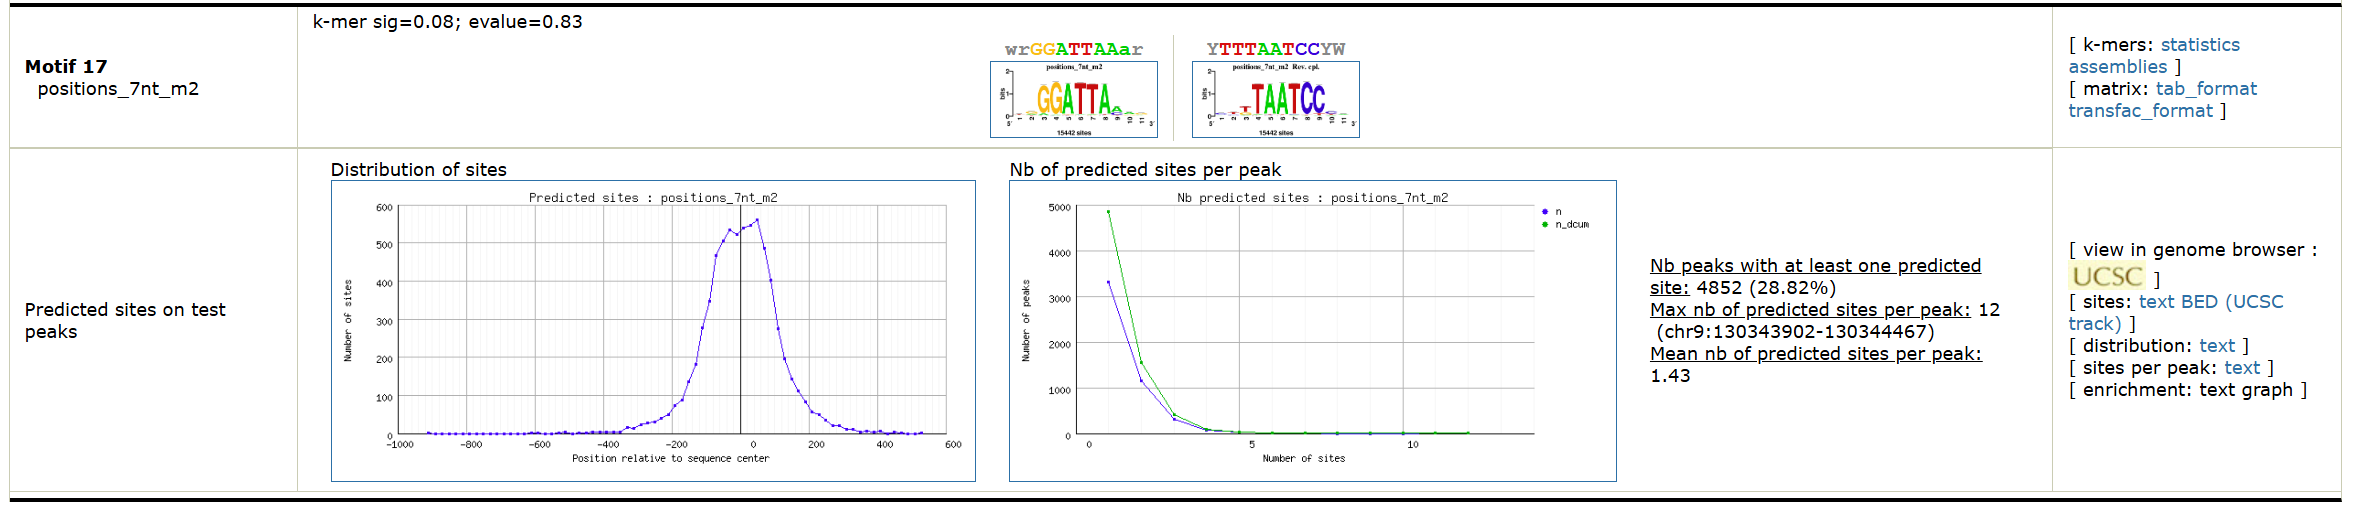

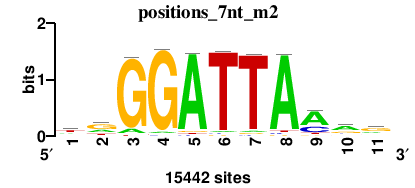

The k-mer with the most significant enrichment has a significance score of 85.45 and an extremely low e-value of 3.5e-86, indicating a highly specific and meaningful motif enrichment.The reverse complement sequence logo shows a `GGGCGGG` core motif, characteristic of potential transcription factor binding sites.The reverse complement sequence logo shows a GGGCGGG core motif, characteristic of potential transcription factor binding sites.A total of 3857 peaks (22.91%) contain at least one predicted binding site, highlighting the prevalence of this motif in the analyzed dataset.

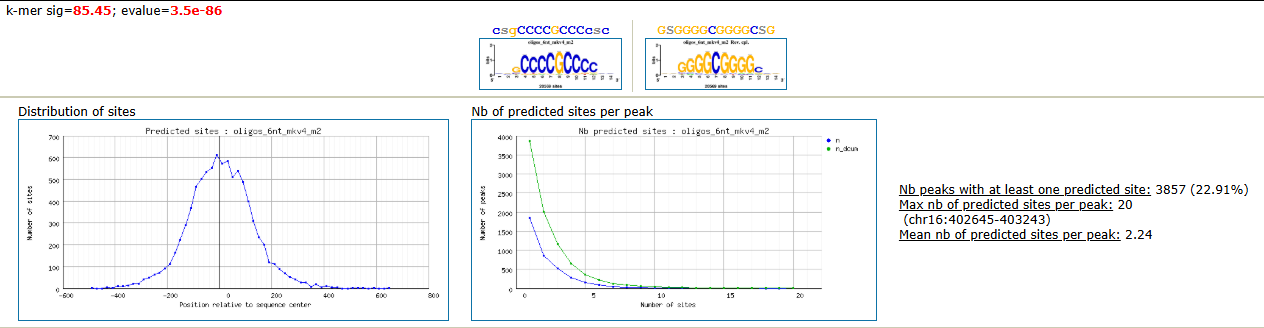

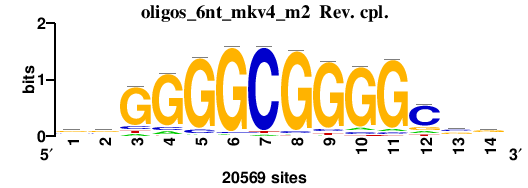

In [3]:
cat ./data/08_motif/peak-motifs_all_motifs_seqcoord.tab | grep -v ";" | grep -v '#' | cut -f 1 | tr "_" "\t" | awk '!a[$0]++' > ./data/08_motif/cells-allpeaks-with-motif-RSAT.bed

In [7]:
head  -3 ./data/08_motif/cells-allpeaks-with-motif-RSAT.bed
wc -l ./data/08_motif/cells-allpeaks-with-motif-RSAT.bed

chr1:1051409-1051873
chr1:1310662-1310991
chr1:1840546-1840985
13143 ./data/08_motif/cells-allpeaks-with-motif-RSAT.bed


### PWM and track enrichment 
Using i-cis-Target, top enriched motifs ranked from motifs database (PWMs). 
This is the link to the results.

We can also find `GGGGCGGGGGC` and `GCCCCGCCCCC` motifs appeared in above analysis. They are identified as the two top-ranked TF motif with the highest enrichment score. 
`SP1` is a zinc-finger transcription factor known to regulate promoters of housekeeping genes and genes involved in chromatin remodeling. Its enrichment suggests a role in maintaining basal transcriptional activity.

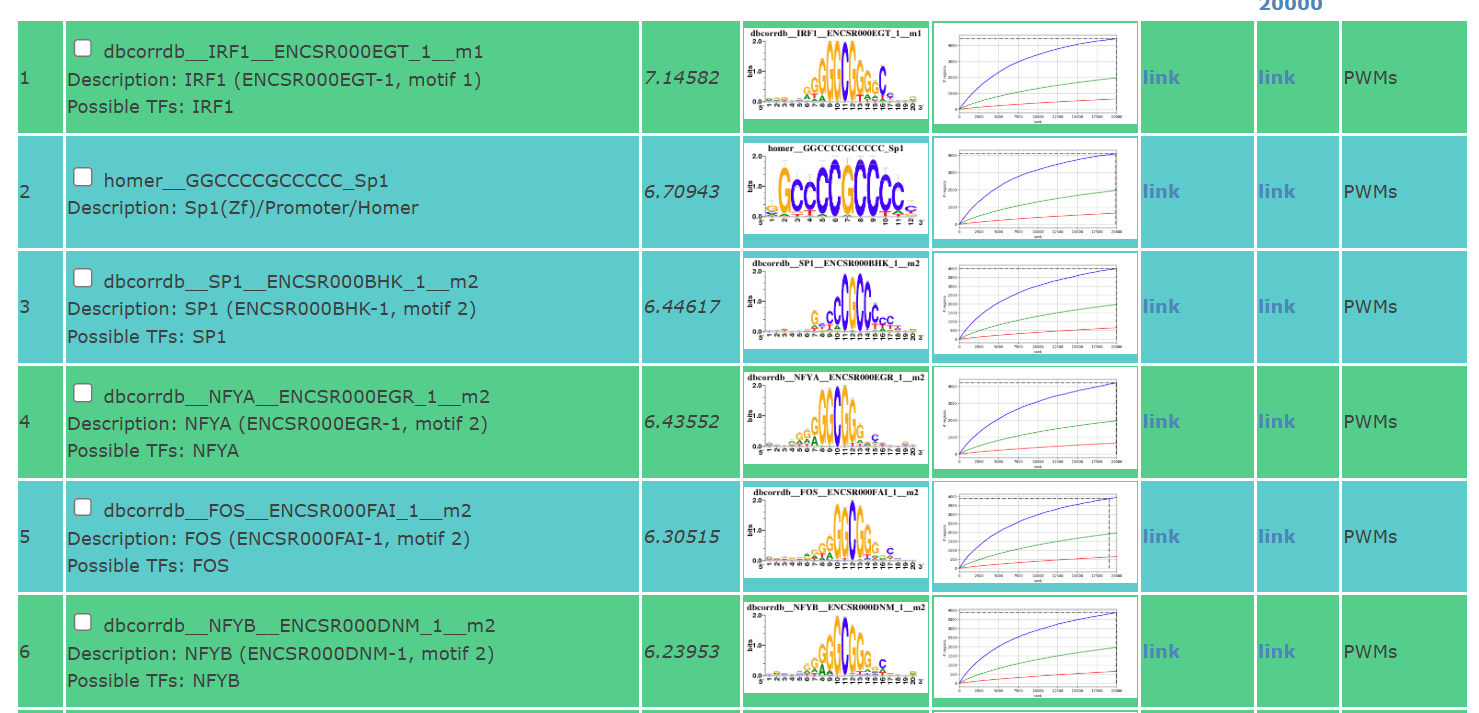

### Additional Functional analysis <!-- id: additional-functional-analysis -->


The motif analysis identifies `IRF1` as a key transcription factor with a strong binding motif (as shown in the figure). The iRegulon analysis further reveals its regulatory potential by identifying 4428 downstream target genes, which are visualized in a network diagram.

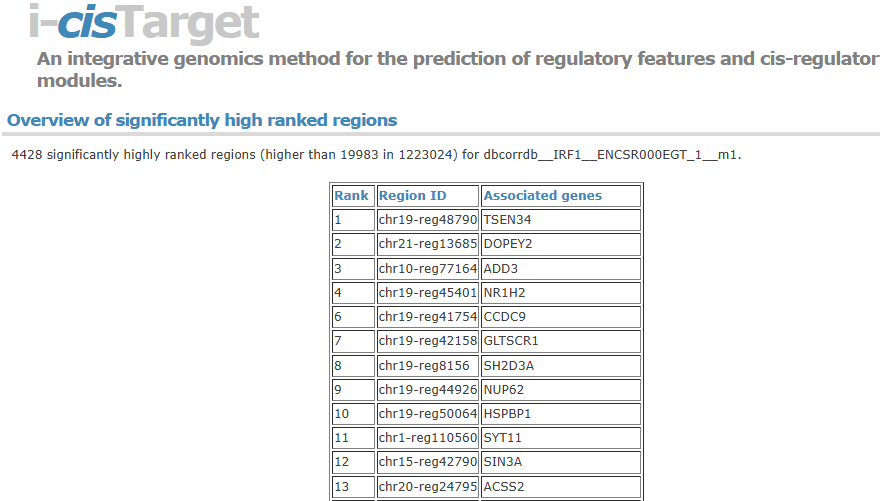

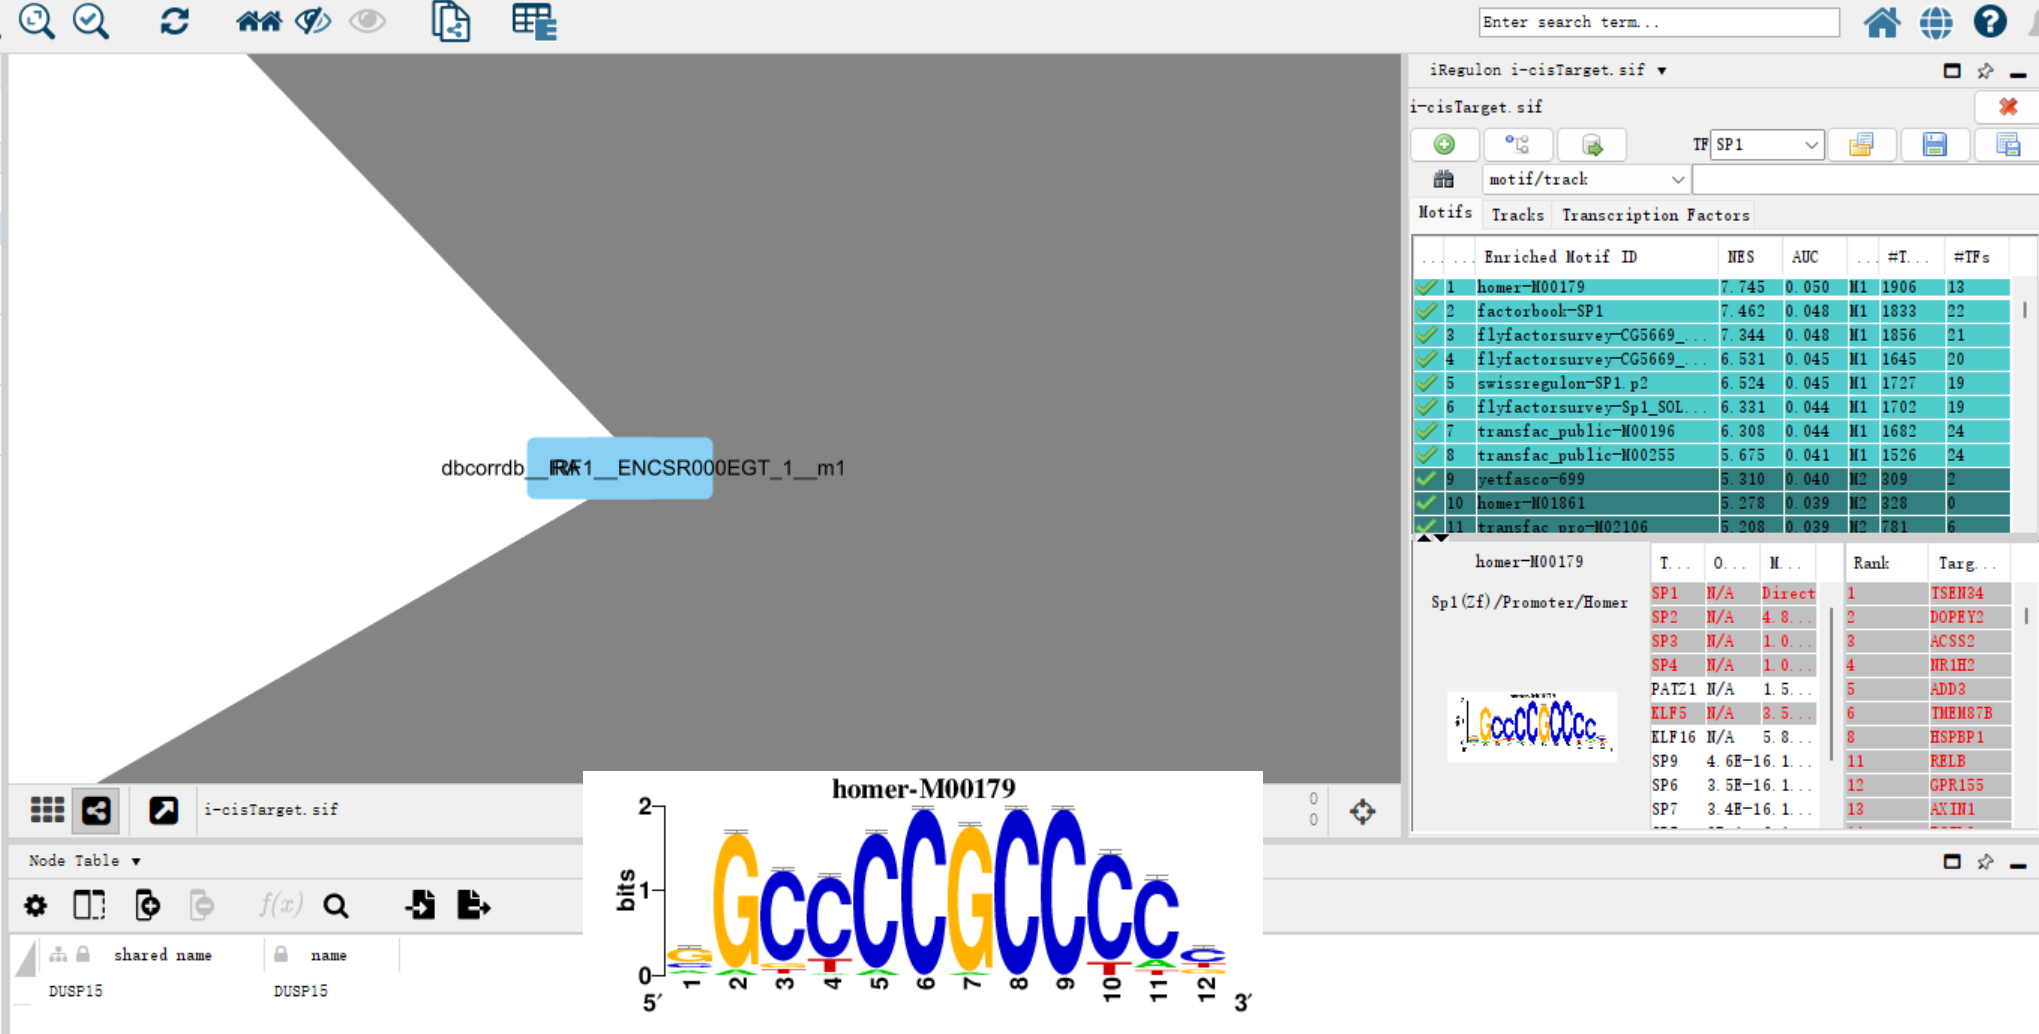

# conclusion
This study utilized a comprehensive ATAC-seq analysis pipeline to investigate chromatin accessibility during human preimplantation development, revealing critical insights into the regulatory mechanisms of early embryogenesis. By examining key stages—2-cell and 8-cell embryos, inner cell masses (ICMs), and human embryonic stem cells (hESCs)—the analysis identified widespread chromatin accessibility at CpG-rich promoters, particularly during minor zygotic genome activation (ZGA), followed by the activation of key transcription factors such as IRF1, PITX1, and GSC during major ZGA. Normalization and visualization of chromatin coverage provided high-resolution insights into open chromatin regions, while motif enrichment analysis highlighted IRF1 as a top regulator, supported by its enriched binding motif (GGGCGGG) and a regulatory network encompassing 4428 downstream target genes. This pipeline revealed a dynamic chromatin landscape driving transcriptional regulation, linking accessibility to lineage specification and early developmental transitions. The results establish a foundational framework for understanding chromatin dynamics in early human development and highlight IRF1 as a pivotal transcription factor, paving the way for experimental validation and cross-species comparative studies.